# 06. 외부 데이터 EDA (상권매출, 상가정보, 관광)

## 이 노트북이 하는 일
카드 데이터 밖의 공개 자료 3종을 살펴보고, **카드 분석 결과를 읽을 때 옆에 놓을 맥락**을 만든다.
- **서울 상권분석 추정매출** (분기, 서울만): 우리 카드 데이터가 강남 소비를 제대로 대표하는지 검증하고, 2021~2025년 장기 추세 속에서 2025년 하반기가 어디쯤인지 본다.
- **상가정보** (2025년 10월, 12월 두 시점): 사라진 가게와 새로 생긴 가게를 세어 공급 쪽 변화를 본다.
- **관광 방문자** (월별, 2021~2025): 춘천과 강남에 사람이 얼마나 왔는지 보고, 카드 데이터2의 외지인 매출 비중과 맞춰 본다.

> ⚠️ 이 노트북은 **"기상이 매출을 얼마나 떨어뜨리는가"에 답하지 않는다.** 세 자료 모두 분기나 월 단위, 또는 두 시점뿐이라 폭염일이나 호우일 하루를 볼 수 없기 때문이다(탐색 문서: "전부 맥락 자료"). 여기서 나온 결과는 05번 결과를 해석하고 보고서의 배경을 쓰는 데 쓴다.

## 답해야 할 질문
1. 카드 데이터(강남)의 업종, 요일, 시간대, 성별, 연령 구성은 서울시 상권매출과 비슷한가? (대표성)
2. 2021~2025년 강남 상권 매출 흐름에서 2025년 3분기(폭염 여름)는 유난히 낮았는가? 3분기는 원래 낮은 분기인가?
3. 2025년 10월 -> 12월 사이 가게는 얼마나 사라지고 생겼나? 업종과 행정동별로 차이가 있나?
4. 관광 방문자 수의 외지인 비중과 카드 데이터2의 외지인 매출 비중은 같은 방향으로 움직이는가?
5. 세 자료 각각으로 할 수 있는 것과 없는 것은 무엇인가?

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 출력 |
|---|---|
| `sales_seoul.parquet`, `stores.parquet`, `tour_dom_trend.parquet`, `tour_dom_home.parquet`, `tour_dom_dong.parquet`, `tour_for_trend.parquet`, `tour_for_dong.parquet`, `tour_for_country.parquet`, `card1.parquet`, `card2.parquet`, `calendar.parquet`, `dong_codes.csv`, `dong_boundary.geojson` | 그래프와 표 (노트북 안). 저장하는 파일은 없음 |

> 01번 노트북을 먼저 실행해서 `preprocessed/` 폴더에 파일이 있어야 한다.
> 전체 실행 순서는 01 -> 02 -> 03 -> 04 -> 07 -> 05 -> 06 이지만, 06번은 **01번의 원본 파일만** 쓰는 맥락 자료라서 01번만 끝나 있으면 언제 해도 된다.

## 이 노트북의 규칙
- 코드 셀에는 **TODO 주석**만 적혀 있다. 주석을 읽고 그 아래에 코드를 채워 넣는다.
- TODO마다 **확인용 참고값**이 있다. 직접 짠 코드의 결과가 이 값과 비슷하면 맞게 한 것이다. (01번 결과로 미리 계산한 값)
- 각 장 끝의 **정리** 칸(본 것 / 나온 것 / 시사점)은 그래프를 본 뒤 한 줄씩 채운다.
- 금액은 **억 원** 단위로 보면 읽기 편한다. (`amount / 1e8`)
- 표를 볼 때는 `print(표)` 대신 **`display(표)`** 를 쓴다. 칸이 나뉜 표로 나와서 보기 편한다. 열 하나짜리(Series)는 `display(s.to_frame())`, 셀 마지막 줄에 표 이름만 적어도 표로 나온다.

## 결과 요약
- **카드 데이터는 총액이 아니라 구성으로 검증된다.** 상권매출과 총액은 0.19배로 맞지 않지만(자료 범위가 다름), 업종그룹 비중 상관 0.93, 요일 0.99, 연령 0.99로 구성과 방향은 잘 맞는다. 그룹 단위 결론은 카드 자체로만 말한다.
- **2025년 3분기는 눌린 분기가 아니었다.** 강남 계절지수 1.022로 5년 중 가장 높고, 6개 분기 연속 감소하던 매출이 처음 증가로 돌아섰다(YoY +2.9%). 분기, 월 합계로는 폭염의 흔적이 보이지 않는다.
- **더위가 늘린 업종이 보인다.** 2025년 3분기 계절지수가 5년 중 최고인 그룹은 카페 1.094, 편의점 1.077, 여가/오락 1.143이고, 평년보다 낮았던 유일한 그룹은 패션/뷰티(0.954)다.
- **개폐업은 절댓값을 믿을 수 없다.** 2개월 폐업률 강남 2.20%, 춘천 2.48%지만 번호 재발급이 3.4 ~ 6.5% 섞여 있다. 상대 비교로만 쓴다. 강남 개포동 일대의 폐업 집중은 재건축 때문으로 날씨와 무관하다.
- **춘천은 관광과 카드가 같이 움직인다**(외지인 비중 상관 0.97, 정의를 맞추면 19.1% 대 18.3%). 강남은 -0.20으로, 외지인 비중이 1%p 안에서만 움직여 상관을 논할 변동 자체가 없다.

## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', message='.*GDAL.*')      # geopandas import보다 먼저

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from IPython.display import display

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
plt.rc('figure', figsize=(12, 4), dpi=110)

REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}
SOURCE_COLOR = {'상권매출': '#2ca02c', '카드': '#1f77b4', '관광': '#9467bd'}
pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 40)
print('pandas', pd.__version__, '| geopandas', gpd.__version__)

pandas 2.2.3 | geopandas 1.1.3


### 0-2. 경로 설정과 데이터 불러오기

In [2]:
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

sales = pd.read_parquet(OUT / 'sales_seoul.parquet')
stores = pd.read_parquet(OUT / 'stores.parquet')
TOUR = ['tour_dom_trend', 'tour_dom_home', 'tour_dom_dong',
        'tour_for_trend', 'tour_for_dong', 'tour_for_country']
tour = {n: pd.read_parquet(OUT / f'{n}.parquet') for n in TOUR}
card1 = pd.read_parquet(OUT / 'card1.parquet')
card2 = pd.read_parquet(OUT / 'card2.parquet')
calendar = pd.read_parquet(OUT / 'calendar.parquet')
dong_codes = pd.read_csv(OUT / 'dong_codes.csv', dtype={'adm_cd8_mois': str})
dong_gdf = gpd.read_file(OUT / 'dong_boundary.geojson')

for n, d in [('sales', sales), ('stores', stores), *tour.items(),
             ('card1', card1), ('card2', card2), ('calendar', calendar),
             ('dong_codes', dong_codes), ('dong_gdf', dong_gdf)]:
    print(f'{n:16s} {d.shape[0]:>8,}행 x {d.shape[1]:2d}열')

sales             343,167행 x 56열
stores            163,252행 x 16열
tour_dom_trend        360행 x  7열
tour_dom_home       2,482행 x  5열
tour_dom_dong         235행 x  5열
tour_for_trend        120행 x  6열
tour_for_dong         235행 x  4열
tour_for_country      238행 x  4열
card1            1,663,909행 x 11열
card2            4,208,127행 x 11열
calendar              184행 x  9열
dong_codes             47행 x  6열
dong_gdf               47행 x  7열


### 0-3. 분석 기본 표 만들기

In [3]:
gn = sales[sales['is_gangnam']].copy()
base1 = card1[card1['is_target'] & card1['sex'].ne('법인')].copy()
base2 = card2[card2['is_target']].copy()

for col in ['상권업종대분류명', '상권업종중분류명']:
    stores[col] = stores[col].str.replace('\u00b7', '/')      # 가운뎃점 -> 슬래시

print('gn', gn.shape, '| 그중 2025년', int((gn['year'] == 2025).sum()))
print('base1', base1.shape, '| base2', base2.shape)
print('상가 대분류:', sorted(stores['상권업종대분류명'].unique()))
print(f"※ 01번 3-2에서 0으로 채운 뒤라 base1 행 수가 늘었다 "
      f"(결제가 있던 행 {int((~base1['is_filled']).sum()):,}개). 금액 기준 값은 그대로다.")

gn (18998, 56) | 그중 2025년 3742
base1 (1285449, 11) | base2 (3494167, 11)
상가 대분류: ['과학/기술', '교육', '보건의료', '부동산', '소매', '수리/개인', '숙박', '시설관리/임대', '예술/스포츠', '음식']
※ 01번 3-2에서 0으로 채운 뒤라 base1 행 수가 늘었다 (결제가 있던 행 826,835개). 금액 기준 값은 그대로다.


## 1. 상권매출 데이터 개요
서울시 상권분석 추정매출은 **행정동 × 서비스 업종(63개) × 분기** 표이다. 카드 데이터와 비교하기 전에 구조와 함정을 먼저 확인한다.

### 1-1. 구조 확인 (분기, 행정동, 업종)

In [4]:
print('분기:', sorted(sales['기준_년분기_코드'].unique()))
display(sales.groupby('기준_년분기_코드')['행정동_코드'].nunique().rename('서울 행정동').to_frame()
        .join(gn.groupby('기준_년분기_코드')['행정동_코드'].nunique().rename('강남 행정동')).T)
업종 = sorted(sales['서비스_업종_코드_명'].unique())
print(f'업종 {len(업종)}개:', 업종[:12], '...')
print('강남 분기별 행 수'); display(gn.groupby(['year', 'quarter']).size().unstack())
print(f"-> 22개 동 x 63개 업종 = 1,386칸 중 약 {gn.groupby(['year', 'quarter']).size().mean() / 1386:.0%}만 있다")

분기: [20211, 20212, 20213, 20214, 20221, 20222, 20223, 20224, 20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244, 20251, 20252, 20253, 20254]


기준_년분기_코드,20211,20212,20213,20214,20221,20222,20223,20224,20231,20232,20233,20234,20241,20242,20243,20244,20251,20252,20253,20254
서울 행정동,424,424,424,424,424,424,424,424,424,424,424,424,424,424,424,424,425,425,425,425
강남 행정동,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22,22


업종 63개: ['PC방', '가구', '가방', '가전제품', '가전제품수리', '고시원', '골프연습장', '네일숍', '노래방', '당구장', '문구', '미곡판매'] ...
강남 분기별 행 수


quarter,1,2,3,4
year,,,,
2021,958,959,956,961
2022,964,963,958,957
2023,953,949,951,952
2024,952,947,938,938
2025,930,936,942,934


-> 22개 동 x 63개 업종 = 1,386칸 중 약 69%만 있다


### 1-2. 성별, 연령 합계가 전체보다 작은 문제

In [5]:
성별합 = sales['남성_매출_금액'] + sales['여성_매출_금액']
유효 = sales['당월_매출_금액'] > 0
print(f'행별 비율의 중앙값: {(성별합[유효] / sales.loc[유효, "당월_매출_금액"]).median():.3f}')
print(f'금액 가중 (서울 전체): {성별합.sum() / sales["당월_매출_금액"].sum():.2f}')

gn25 = gn[gn['year'].eq(2025) & gn['quarter'].isin([3, 4])]
print(f'금액 가중 (강남 2025년 3~4분기): '
      f'{(gn25["남성_매출_금액"] + gn25["여성_매출_금액"]).sum() / gn25["당월_매출_금액"].sum():.2f}')

연도별 = gn.groupby('year').apply(
    lambda d: (d['남성_매출_금액'] + d['여성_매출_금액']).sum() / d['당월_매출_금액'].sum(), include_groups=False)
print('강남 연도별'); display(연도별.round(2).to_frame('성별 합계 / 당월 매출').T)

행별 비율의 중앙값: 0.985
금액 가중 (서울 전체): 0.89
금액 가중 (강남 2025년 3~4분기): 0.87
강남 연도별


year,2021,2022,2023,2024,2025
성별 합계 / 당월 매출,0.9,0.9,0.9,0.9,0.9


### 1장 정리
- **본 것**: 상권매출의 구조(1-1), 성별과 연령 합계가 전체보다 작은 문제(1-2)
- **나온 것**:
  - 20개 분기(2021Q1~2025Q4), 서울 행정동 424~425개, 강남 22개 동, 업종 63개
  - 강남은 22개 동 x 63개 업종 = 1,386칸 중 **약 3분의 2만** 행이 있다(매출이 없는 조합은 행 자체가 없음)
  - 성별 합계 / 당월 매출은 행별 중앙값으로는 0.985지만 **금액 가중으로는 서울 0.89, 강남 2025년 0.87**
- **시사점**:
  - 성별과 연령 비중은 반드시 **성별 합계 또는 연령 합계를 분모로** 계산해야 한다(3-6에서 그렇게 했다)
  - 이 자료는 골목상권 업종 위주라 **백화점, 대형마트, 주유소, 택시가 없다.** 카드와 총액을 맞출 수 없는 근본 이유다

## 2. 업종 연결표 만들기
상권매출의 업종(63개)과 카드 데이터의 업종(91개, 업종그룹 14개)은 이름도 나누는 방식도 다르다.
두 자료를 비교하려면 **상권매출 업종을 카드 업종그룹에 연결하는 사전**이 필요한다. 업종 하나하나보다 **업종그룹 단위**로 맞추는 게 현실적이다.

### 2-1. 상권매출 업종 -> 카드 업종그룹 사전

In [6]:
SALES_TO_GROUP = {
    # 음식점 (8)
    '한식음식점': '음식점', '중식음식점': '음식점', '일식음식점': '음식점', '양식음식점': '음식점',
    '분식전문점': '음식점', '치킨전문점': '음식점', '패스트푸드점': '음식점', '제과점': '음식점',
    # 카페, 주점, 편의점
    '커피-음료': '카페', '호프-간이주점': '주점/유흥', '편의점': '편의점',
    # 식료품 (6)
    '슈퍼마켓': '식료품', '청과상': '식료품', '수산물판매': '식료품', '육류판매': '식료품',
    '미곡판매': '식료품', '반찬가게': '식료품',
    # 패션/뷰티 (7)
    '일반의류': '패션/뷰티', '한복점': '패션/뷰티', '신발': '패션/뷰티', '가방': '패션/뷰티',
    '섬유제품': '패션/뷰티', '화장품': '패션/뷰티', '시계및귀금속': '패션/뷰티',
    # 생활/취미용품 (14)
    '가구': '생활/취미용품', '가전제품': '생활/취미용품', '철물점': '생활/취미용품', '조명용품': '생활/취미용품',
    '인테리어': '생활/취미용품', '서적': '생활/취미용품', '문구': '생활/취미용품', '완구': '생활/취미용품',
    '운동/경기용품': '생활/취미용품', '애완동물': '생활/취미용품', '핸드폰': '생활/취미용품',
    '컴퓨터및주변장치판매': '생활/취미용품', '안경': '생활/취미용품', '자전거 및 기타운송장비': '생활/취미용품',
    '화초': '생활/취미용품',                 # 원예용품. 취미 쪽으로 본다
    # 의료 (5)
    '일반의원': '의료', '치과의원': '의료', '한의원': '의료', '의약품': '의료', '의료기기': '의료',
    # 미용/생활서비스 (5)
    '미용실': '미용/생활서비스', '네일숍': '미용/생활서비스', '피부관리실': '미용/생활서비스',
    '세탁소': '미용/생활서비스', '가전제품수리': '미용/생활서비스',
    # 여가/오락 (3), 스포츠시설 (3), 교통/차량 (2), 숙박 (1)
    '노래방': '여가/오락', 'PC방': '여가/오락', '당구장': '여가/오락',
    '골프연습장': '스포츠시설', '스포츠클럽': '스포츠시설', '스포츠 강습': '스포츠시설',
    '자동차수리': '교통/차량', '자동차미용': '교통/차량',
    '여관': '숙박/여행',                      # 상권매출의 유일한 숙박 업종
    # 제외 (6): 카드에서도 제외인 업종들
    '일반교습학원': '제외', '외국어학원': '제외', '예술학원': '제외',
    '부동산중개업': '제외', '고시원': '제외',   # 고시원은 사실상 주거
    '전자상거래업': '제외',                     # 온라인이라 지역 상권이 아님
}

빠진 = set(sales['서비스_업종_코드_명'].unique()) - set(SALES_TO_GROUP)
print('빠진 업종:', 빠진 or '없음')
sales['group'] = sales['서비스_업종_코드_명'].map(SALES_TO_GROUP)
gn = sales[sales['is_gangnam']].copy()
display(pd.Series(SALES_TO_GROUP).value_counts().rename('업종 수').to_frame().T)

빠진 업종: 없음


,생활/취미용품,음식점,패션/뷰티,식료품,제외,의료,미용/생활서비스,여가/오락,스포츠시설,교통/차량,카페,주점/유흥,편의점,숙박/여행
업종 수,15,8,7,6,6,5,5,3,3,2,1,1,1,1


### 2-2. 연결 결과 확인 (어느 쪽에만 있는 그룹)

In [7]:
gn25 = gn[gn['year'].eq(2025) & gn['quarter'].isin([3, 4])]
상권비중 = (gn25.groupby('group')['당월_매출_금액'].sum() / gn25['당월_매출_금액'].sum() * 100)
print('상권매출 강남 2025년 3~4분기 그룹 비중(%)'); display(상권비중.sort_values(ascending=False).round(1).to_frame().T)

카드그룹 = set(card1['industry_group'].unique()) - {'제외'}
상권그룹 = set(상권비중.index) - {'제외'}
print('카드에만 있는 그룹:', 카드그룹 - 상권그룹, '| 상권매출에만:', 상권그룹 - 카드그룹)
COMMON = sorted(카드그룹 & 상권그룹)
print(f'COMMON {len(COMMON)}개:', COMMON)

상권매출 강남 2025년 3~4분기 그룹 비중(%)


group,음식점,의료,패션/뷰티,제외,생활/취미용품,식료품,편의점,카페,미용/생활서비스,주점/유흥,스포츠시설,교통/차량,여가/오락,숙박/여행
당월_매출_금액,24.9,24.4,12.7,9.8,6.9,5.1,4.6,3.5,2.6,2.6,1.5,0.7,0.6,0.1


카드에만 있는 그룹: {'대형유통'} | 상권매출에만: set()
COMMON 13개: ['교통/차량', '미용/생활서비스', '생활/취미용품', '숙박/여행', '스포츠시설', '식료품', '여가/오락', '음식점', '의료', '주점/유흥', '카페', '패션/뷰티', '편의점']


### 2장 정리
- **본 것**: 상권매출 63개 업종을 카드 업종그룹에 연결(2-1), 연결 결과 확인(2-2)
- **나온 것**:
  - 63개를 모두 연결했다. 생활/취미용품 15개, 음식점 8개, 패션/뷰티 7개, 식료품 6개, 제외 6개 순
  - **카드에만 있는 그룹은 대형유통**(백화점, 쇼핑몰, 면세점)이다. 상권매출에는 이 업종이 없다
  - 비교에 쓸 COMMON은 **13개 그룹**(카드 14개 - 대형유통, 양쪽 모두 제외는 뺌)
- **시사점**:
  - 같은 그룹 이름이어도 **속이 다르다.** 카드 교통/차량은 주유소와 택시가 크지만 상권매출은 자동차수리뿐이고,
    카드 숙박/여행은 호텔과 여행사까지지만 상권매출은 여관뿐이다. 그룹 비중 차이를 볼 때 이 점을 먼저 확인해야 한다
  - > [추론] 화초, 안경처럼 어디에 넣어도 말이 되는 업종이 있다. 여기서는 화초와 안경을 생활/취미용품에 넣었고, 이 선택이 패션/뷰티와 생활/취미용품 비중을 0.5%p 안팎 움직인다

## 3. 카드 데이터 대표성 검증 (강남, 2025년 3~4분기)
카드 데이터는 한 카드사 자료이다. 서울시 상권매출과 **구성(비중)** 이 비슷하면 "카드 데이터가 강남 소비를 크게 왜곡하지 않는다"고 말할 수 있다.
두 자료는 범위가 달라서 **총액(수준)은 비교하기 어렵고, 비중(구성)과 변화 방향을 비교**하는 게 핵심이다.
카드 데이터 기간(2025-07-01 ~ 12-31)은 상권매출의 **2025년 3분기 + 4분기**와 정확히 같다.

### 3-1. 총 규모 비교

In [8]:
억 = 1e8
상권 = gn25['당월_매출_금액'].sum() / 억
print(f'상권매출 강남 2025년 3~4분기: {상권:,.0f}억 원')
display((gn25.groupby('quarter')['당월_매출_금액'].sum() / 억).round(0).to_frame('억 원').T)

c강남 = card1[card1['region'].eq('강남')]
행 = {'card1 전체': c강남['amount'].sum() / 억,
      '분석 대상 업종': c강남.loc[c강남['is_target'], 'amount'].sum() / 억,
      'base1 (대상 + 개인)': base1.loc[base1['region'].eq('강남'), 'amount'].sum() / 억}
display(pd.Series(행).round(0).to_frame('억 원').T)
print(f"상권매출 / card1 전체 = {상권 / 행['card1 전체']:.2f}, / 분석 대상 = {상권 / 행['분석 대상 업종']:.2f}")

상권C = gn25[gn25['group'].isin(COMMON)]['당월_매출_금액'].sum() / 억
카드C = c강남[c강남['industry_group'].isin(COMMON)]['amount'].sum() / 억
카드C개인 = base1[base1['region'].eq('강남') & base1['industry_group'].isin(COMMON)]['amount'].sum() / 억
print(f'COMMON 그룹만: 상권 {상권C:,.0f}억 vs 카드 {카드C:,.0f}억 ({상권C / 카드C:.2f}), '
      f'카드 개인만 {카드C개인:,.0f}억 ({상권C / 카드C개인:.2f})')

상권매출 강남 2025년 3~4분기: 65,049억 원


quarter,3,4
억 원,"32,318.0","32,731.0"


,card1 전체,분석 대상 업종,base1 (대상 + 개인)
억 원,"334,941.0","116,076.0","96,825.0"


상권매출 / card1 전체 = 0.19, / 분석 대상 = 0.56


COMMON 그룹만: 상권 58,696억 vs 카드 98,753억 (0.59), 카드 개인만 81,025억 (0.72)


### 3-2. 업종그룹 구성 비교

,상권,카드,카드(개인만)
의료,27.0,30.9,36.6
음식점,27.6,25.2,19.0
식료품,5.7,13.5,15.0
패션/뷰티,14.0,7.0,7.9
생활/취미용품,7.7,5.6,5.5
카페,3.9,4.9,4.4
교통/차량,0.8,2.7,2.3
편의점,5.1,2.6,2.8
숙박/여행,0.1,2.4,1.4
미용/생활서비스,2.9,2.1,2.3


상관 0.93 (순위 0.84), 개인만 0.87


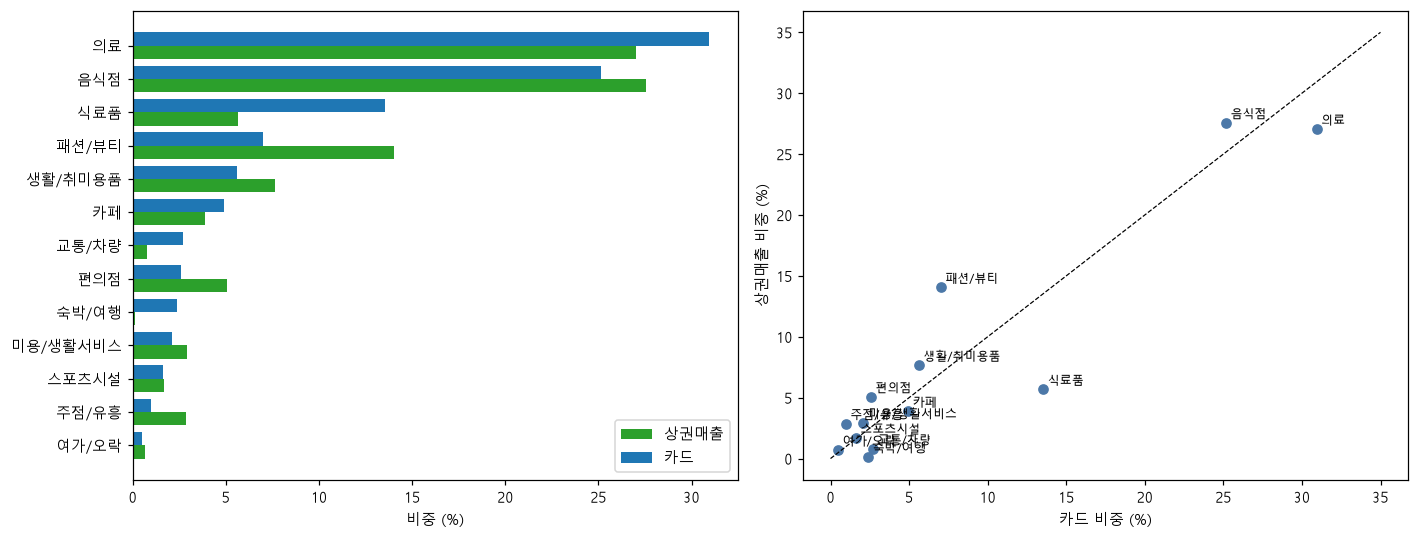

In [9]:
s = (gn25[gn25['group'].isin(COMMON)].groupby('group')['당월_매출_금액'].sum())
c = (c강남[c강남['industry_group'].isin(COMMON)].groupby('industry_group')['amount'].sum())
c개인 = (base1[base1['region'].eq('강남') & base1['industry_group'].isin(COMMON)]
         .groupby('industry_group')['amount'].sum())
comp = pd.DataFrame({'상권': s / s.sum() * 100, '카드': c / c.sum() * 100,
                     '카드(개인만)': c개인 / c개인.sum() * 100}).fillna(0)
display(comp.sort_values('카드', ascending=False).round(1))
print(f"상관 {comp['상권'].corr(comp['카드']):.2f} (순위 {comp['상권'].corr(comp['카드'], method='spearman'):.2f}), "
      f"개인만 {comp['상권'].corr(comp['카드(개인만)']):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
t = comp.sort_values('카드')
axes[0].barh(np.arange(len(t)) - 0.2, t['상권'], height=0.4, color=SOURCE_COLOR['상권매출'], label='상권매출')
axes[0].barh(np.arange(len(t)) + 0.2, t['카드'], height=0.4, color=SOURCE_COLOR['카드'], label='카드')
axes[0].set_yticks(range(len(t))); axes[0].set_yticklabels(t.index); axes[0].set_xlabel('비중 (%)'); axes[0].legend()
axes[1].scatter(comp['카드'], comp['상권'], color='#4C78A8')
for g in comp.index:
    axes[1].annotate(g, (comp.loc[g, '카드'], comp.loc[g, '상권']), fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[1].plot([0, 35], [0, 35], ls='--', color='k', lw=0.8)
axes[1].set(xlabel='카드 비중 (%)', ylabel='상권매출 비중 (%)')
plt.tight_layout(); plt.show()

### 3-3. 이름이 같은 업종끼리 1:1 비교

,상권매출 업종,카드 업종,상권(억),카드(억),상권/카드
9,슈퍼마켓,할인점/슈퍼마켓/양판점,"1,355.1","11,699.5",0.1
0,커피-음료,커피전문점,"2,274.7","4,864.7",0.5
7,일반의원,일반병원,"9,529.9","15,574.3",0.6
3,제과점,제과점,514.4,795.0,0.7
5,치과의원,치과병원,"1,345.9","2,045.2",0.7
6,한의원,한의원,522.7,791.6,0.7
13,패스트푸드점,패스트푸드,354.9,513.0,0.7
4,미용실,미용실,"1,153.9","1,631.5",0.7
2,한식음식점,한식,"10,172.3","11,125.7",0.9
1,편의점,편의점,"2,974.5","2,538.6",1.2


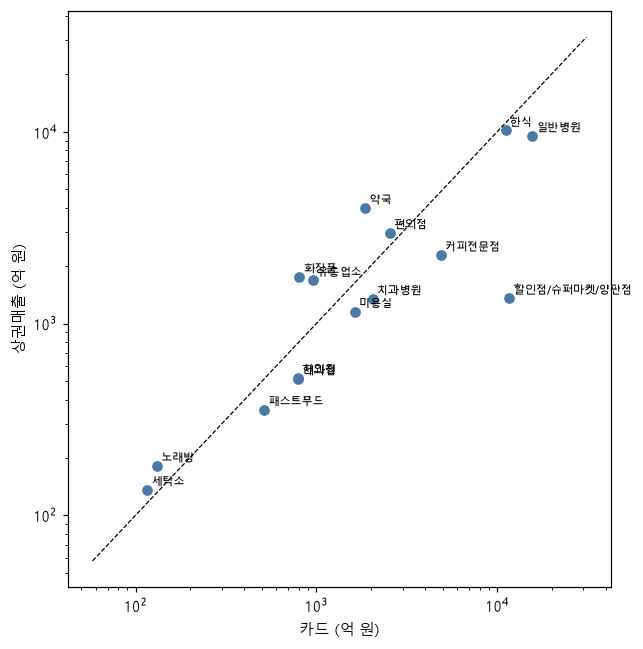

In [10]:
PAIR = {'커피-음료': '커피전문점', '편의점': '편의점', '한식음식점': '한식', '제과점': '제과점',
        '미용실': '미용실', '치과의원': '치과병원', '한의원': '한의원', '일반의원': '일반병원',
        '의약품': '약국', '슈퍼마켓': '할인점/슈퍼마켓/양판점', '노래방': '노래방', '세탁소': '세탁소',
        '화장품': '화장품', '패스트푸드점': '패스트푸드', '호프-간이주점': '유흥업소'}

행 = []
for s이름, c이름 in PAIR.items():
    a = gn25.loc[gn25['서비스_업종_코드_명'].eq(s이름), '당월_매출_금액'].sum() / 억
    b = c강남.loc[c강남['industry'].eq(c이름), 'amount'].sum() / 억
    행.append({'상권매출 업종': s이름, '카드 업종': c이름, '상권(억)': a, '카드(억)': b, '상권/카드': a / b if b else np.nan})
t = pd.DataFrame(행).sort_values('상권/카드')
display(t.round(2))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(t['카드(억)'], t['상권(억)'], color='#4C78A8')
for _, r in t.iterrows():
    ax.annotate(r['카드 업종'], (r['카드(억)'], r['상권(억)']), fontsize=7, xytext=(3, 3), textcoords='offset points')
lim = [t[['카드(억)', '상권(억)']].min().min() * 0.5, t[['카드(억)', '상권(억)']].max().max() * 2]
ax.plot(lim, lim, 'k--', lw=0.8); ax.set(xscale='log', yscale='log', xlabel='카드 (억 원)', ylabel='상권매출 (억 원)')
plt.tight_layout(); plt.show()

### 3-4. 요일 구성 비교

,월,화,수,목,금,토,일
상권매출,15.0,16.5,15.4,15.3,16.5,13.9,7.4
카드 분석 대상,14.7,16.2,15.6,15.1,16.1,13.5,8.9
카드 전체,18.2,16.4,17.7,16.6,17.9,7.8,5.5
카드 COMMON,14.8,16.3,15.7,15.3,16.5,13.4,8.0


카드 분석 대상 상관 0.99
카드 전체 상관 0.84
카드 COMMON 상관 1.00


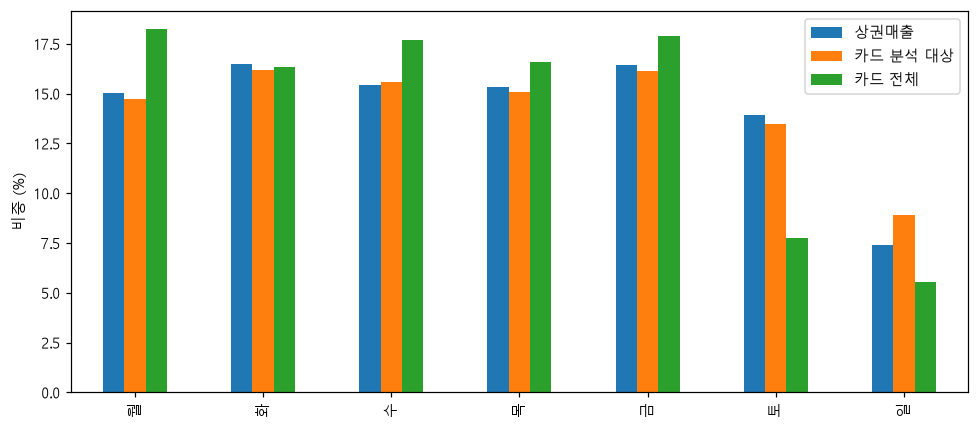

In [11]:
요일열 = ['월요일_매출_금액', '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액',
          '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액']
상권요일 = gn25[요일열].sum()
상권요일.index = list('월화수목금토일')
상권요일 = 상권요일 / 상권요일.sum() * 100

cal = calendar[['date', 'dow_name']]
def 카드요일(df):
    t = df.merge(cal, on='date').groupby('dow_name')['amount'].sum().reindex(list('월화수목금토일'))
    return t / t.sum() * 100

t = pd.DataFrame({
    '상권매출': 상권요일,
    '카드 분석 대상': 카드요일(c강남[c강남['is_target']]),
    '카드 전체': 카드요일(c강남),
    '카드 COMMON': 카드요일(c강남[c강남['industry_group'].isin(COMMON)]),
})
display(t.round(1).T)
for c_ in t.columns[1:]:
    print(f"{c_} 상관 {t['상권매출'].corr(t[c_]):.2f}")

ax = t[['상권매출', '카드 분석 대상', '카드 전체']].plot(kind='bar', figsize=(9, 4))
ax.set(ylabel='비중 (%)', xlabel=''); plt.tight_layout(); plt.show()

### 3-5. 시간대 구성 비교 (시간대 구간이 다름)

상권매출 6구간 비중(%)


,00~06,06~11,11~14,14~17,17~21,21~24
0,2.6,10.6,28.3,23.5,26.7,8.3


,새벽,오전,낮,저녁밤
상권매출,2.6,10.6,51.8,35.0
카드,2.4,21.4,50.6,25.6


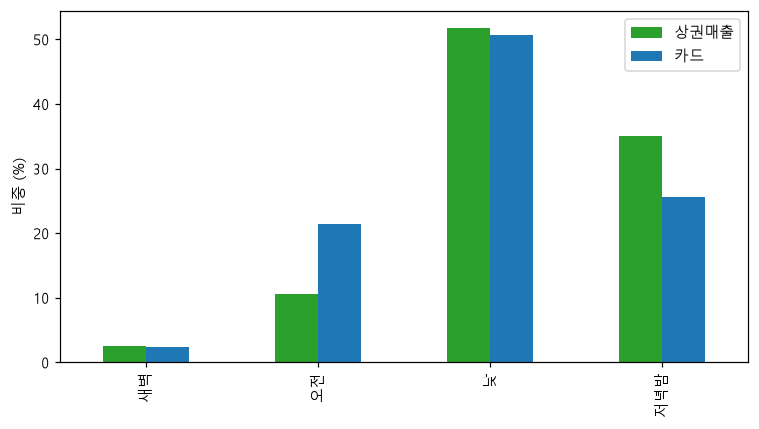

In [12]:
시간열 = ['시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
          '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']
gC = gn25[gn25['group'].isin(COMMON)]
상권6 = gC[시간열].sum(); 상권6.index = ['00~06', '06~11', '11~14', '14~17', '17~21', '21~24']
상권6 = 상권6 / 상권6.sum() * 100
print('상권매출 6구간 비중(%)'); display(상권6.round(1).to_frame().T)

상권4 = pd.Series({'새벽': 상권6['00~06'], '오전': 상권6['06~11'],
                   '낮': 상권6['11~14'] + 상권6['14~17'], '저녁밤': 상권6['17~21'] + 상권6['21~24']})
cC = c강남[c강남['industry_group'].isin(COMMON)]
카드4 = cC.groupby('time_gb')['amount'].sum()
카드4 = (카드4 / 카드4.sum() * 100).rename(index={'00_05': '새벽', '06_11': '오전', '12_17': '낮', '18_23': '저녁밤'})
t = pd.DataFrame({'상권매출': 상권4, '카드': 카드4.reindex(['새벽', '오전', '낮', '저녁밤'])})
display(t.round(1).T)
t.plot(kind='bar', figsize=(7, 4), color=[SOURCE_COLOR['상권매출'], SOURCE_COLOR['카드']])
plt.ylabel('비중 (%)'); plt.tight_layout(); plt.show()

### 3-6. 성별, 연령 구성 비교

성별 (남/여 %): 상권 49.1 / 50.9, 카드 50.2 / 49.8


,10대,20대,30대,40대,50대,60대 이상
상권매출,0.6,12.3,25.0,23.8,20.6,17.7
카드,0.5,10.8,23.9,25.6,21.8,17.4


연령 비중 상관 0.99


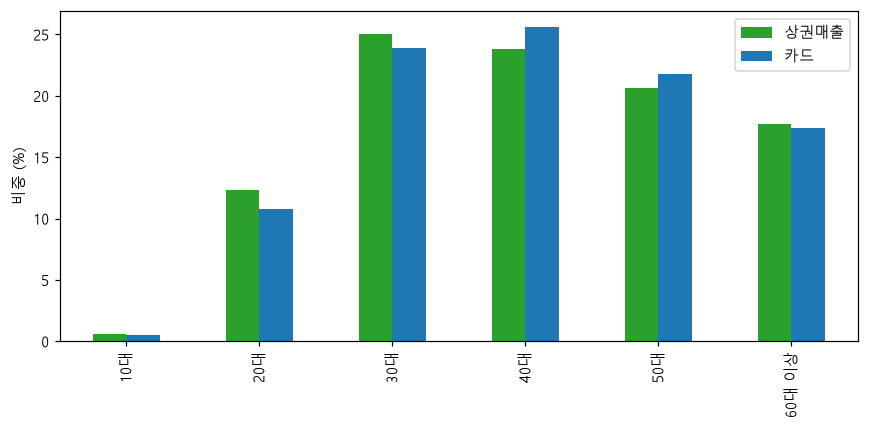

In [13]:
남, 여 = gC['남성_매출_금액'].sum(), gC['여성_매출_금액'].sum()
cC개인 = base1[base1['region'].eq('강남') & base1['industry_group'].isin(COMMON)]
c남 = cC개인.loc[cC개인['sex'].eq('남성'), 'amount'].sum()
c여 = cC개인.loc[cC개인['sex'].eq('여성'), 'amount'].sum()
print(f'성별 (남/여 %): 상권 {남 / (남 + 여) * 100:.1f} / {여 / (남 + 여) * 100:.1f}, '
      f'카드 {c남 / (c남 + c여) * 100:.1f} / {c여 / (c남 + c여) * 100:.1f}')

연령열 = ['연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
          '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액']
상권연령 = gC[연령열].sum(); 상권연령.index = ['10대', '20대', '30대', '40대', '50대', '60대 이상']
상권연령 = 상권연령 / 상권연령.sum() * 100

AGE_GROUP = {'60대': '60대 이상', '70대': '60대 이상', '80대': '60대 이상', '90대': '60대 이상'}
카드연령 = (cC개인.assign(age_g=cC개인['age'].replace(AGE_GROUP)).groupby('age_g')['amount'].sum())
카드연령 = (카드연령 / 카드연령.sum() * 100).reindex(상권연령.index)

t = pd.DataFrame({'상권매출': 상권연령, '카드': 카드연령})
display(t.round(1).T)
print(f"연령 비중 상관 {t['상권매출'].corr(t['카드']):.2f}")
t.plot(kind='bar', figsize=(8, 4), color=[SOURCE_COLOR['상권매출'], SOURCE_COLOR['카드']])
plt.ylabel('비중 (%)'); plt.tight_layout(); plt.show()

### 3-7. 3분기 -> 4분기 변화 방향 비교

합계 4분기 / 3분기: {'상권': 1.029, '카드': 1.029}


,상권,카드
교통/차량,0.991,0.929
미용/생활서비스,0.999,0.941
생활/취미용품,1.161,1.026
숙박/여행,0.999,1.366
스포츠시설,0.863,0.927
식료품,0.978,1.020
여가/오락,0.923,0.925
음식점,1.027,1.017
의료,1.033,1.055
주점/유흥,0.951,0.966


그룹별 비율 상관 0.35


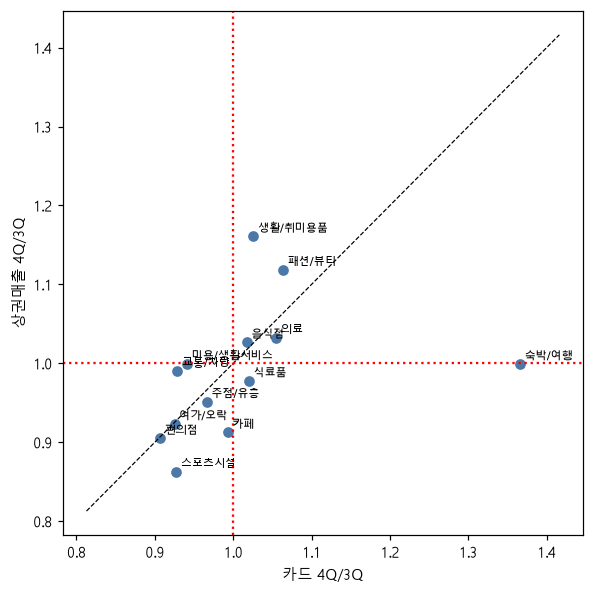

In [14]:
카드q = c강남[c강남['industry_group'].isin(COMMON)].assign(quarter=lambda d: d['date'].dt.quarter)
상권q = gn25[gn25['group'].isin(COMMON)]

합 = pd.DataFrame({
    '상권': 상권q.groupby('quarter')['당월_매출_금액'].sum(),
    '카드': 카드q.groupby('quarter')['amount'].sum()})
print('합계 4분기 / 3분기:', (합.loc[4] / 합.loc[3]).round(3).to_dict())

t = pd.DataFrame({
    '상권': 상권q.pivot_table(index='group', columns='quarter', values='당월_매출_금액', aggfunc='sum').pipe(lambda d: d[4] / d[3]),
    '카드': 카드q.pivot_table(index='industry_group', columns='quarter', values='amount', aggfunc='sum').pipe(lambda d: d[4] / d[3])})
with pd.option_context('display.float_format', '{:.3f}'.format):
    display(t)
print(f"그룹별 비율 상관 {t['상권'].corr(t['카드']):.2f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(t['카드'], t['상권'], color='#4C78A8')
for g in t.index:
    ax.annotate(g, (t.loc[g, '카드'], t.loc[g, '상권']), fontsize=7, xytext=(3, 3), textcoords='offset points')
lim = [t.min().min() - 0.05, t.max().max() + 0.05]
ax.plot(lim, lim, 'k--', lw=0.8); ax.axhline(1, ls=':', color='r'); ax.axvline(1, ls=':', color='r')
ax.set(xlabel='카드 4Q/3Q', ylabel='상권매출 4Q/3Q'); plt.tight_layout(); plt.show()

**결정**: 카드 데이터의 대표성을 보고서에 어떻게 쓸지 적어 둔다.

- **결정**: "카드 데이터의 **업종그룹 구성(상관 0.93), 요일 구성(0.99), 성별과 연령 구성(0.99), 분기 변화 방향(1.029 대 1.029)이
  서울시 상권분석 추정매출과 일치**한다. 따라서 강남 소비 구조를 크게 왜곡하지 않는다고 본다.
  단 **식료품, 교통/차량, 숙박/여행, 패션/뷰티는 두 자료의 업종 범위가 달라 직접 비교하지 않는다.**"
- **이유**: 총액은 상권매출이 카드의 60% 수준이라 맞출 수 없지만(추정값이고 업종 범위가 좁다), 비중과 변화 방향은 잘 맞는다.
  구성이 맞으면 "이 카드사 고객이 특이한 집단이 아니다"라고 말할 수 있고, 그게 대표성 주장에 필요한 전부다.

### 3장 정리
- **본 것**: 총 규모(3-1), 업종그룹 구성(3-2), 업종 1:1(3-3), 요일(3-4), 시간대(3-5), 성별과 연령(3-6), 분기 변화(3-7)
- **나온 것**:
  - 총액은 맞지 않는다. 상권매출 6조 5,049억 vs card1 전체 33조 4,941억(0.19배). COMMON 그룹만 봐도 0.59배
  - **구성은 잘 맞는다.** 업종그룹 비중 상관 0.93(순위 0.84), 요일 상관 0.99, 연령 상관 0.99, 성별 1%p 이내
  - 요일은 제외 업종을 넣으면 상관이 0.84로 떨어진다(주말 비중이 반토막). **01번에서 제외 업종을 뺀 것이 옳았다는 근거**
  - 시간대는 구간이 달라(11시와 17시가 서로 다른 칸) 정밀 비교가 불가능하다. 구간이 같은 새벽만 2.6 vs 2.4로 거의 같다
  - 3분기 → 4분기 변화는 합계로 **1.029 대 1.029**로 똑같지만, 그룹별 비율의 상관은 0.35로 약하다
- **시사점**:
  - 카드 데이터는 **구성과 방향에서 대표성이 있다.** 총액과 업종 단위 금액은 비교하지 않는다
  - 그룹별 움직임까지 맞지는 않으므로, **그룹 단위 결론은 카드 자체로만 말하고 상권매출로 뒷받침하지 않는다**

## 4. 강남 상권 장기 추세 (2021~2025)
카드 데이터는 2025년 하반기뿐이라 "올여름이 평소보다 나빴는지" 알 수 없다. 상권매출 5년치로 **2025년 3분기(폭염 여름)가 긴 흐름에서 어디쯤인지** 본다.
분기 단위라 폭염 효과를 분리할 수는 없고, "3분기가 유난히 낮았는가" 정도만 말할 수 있다.

### 4-1. 강남 분기별 총매출 추이

quarter,1,2,3,4
year,,,,
2021,"28,117.0","30,713.0","29,319.0","33,113.0"
2022,"29,650.0","32,870.0","32,803.0","33,799.0"
2023,"32,710.0","32,116.0","32,215.0","33,332.0"
2024,"32,388.0","31,660.0","31,406.0","32,334.0"
2025,"30,901.0","30,487.0","32,318.0","32,731.0"


연도 합계(조 원): {2021: 12.13, 2022: 12.91, 2023: 13.04, 2024: 12.78, 2025: 12.64}


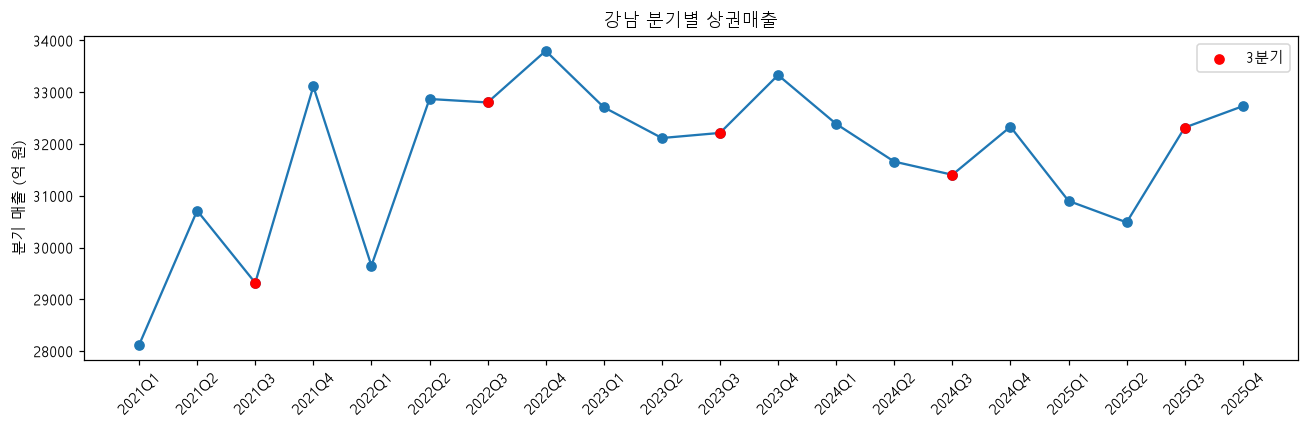

In [15]:
q = gn.groupby(['year', 'quarter'])['당월_매출_금액'].sum() / 억
display(q.unstack().round(0))
print('연도 합계(조 원):', (q.groupby('year').sum() / 10000).round(2).to_dict())

fig, ax = plt.subplots(figsize=(12, 4))
라벨 = [f'{y}Q{n}' for y, n in q.index]
ax.plot(라벨, q.values, marker='o', color=REGION_COLOR['강남'])
q3 = [i for i, (y, n) in enumerate(q.index) if n == 3]
ax.scatter([라벨[i] for i in q3], q.values[q3], color='red', zorder=3, label='3분기')
ax.set(ylabel='분기 매출 (억 원)', title='강남 분기별 상권매출'); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 4-2. 서울 전체와 비교

서울 분기 매출(조 원): {(2021, 1): 22.2, (2021, 2): 23.8, (2021, 3): 23.5} ...
강남 비중(%): 2021Q1 12.6 -> 2025Q4 12.0 | 2025Q3 12.4


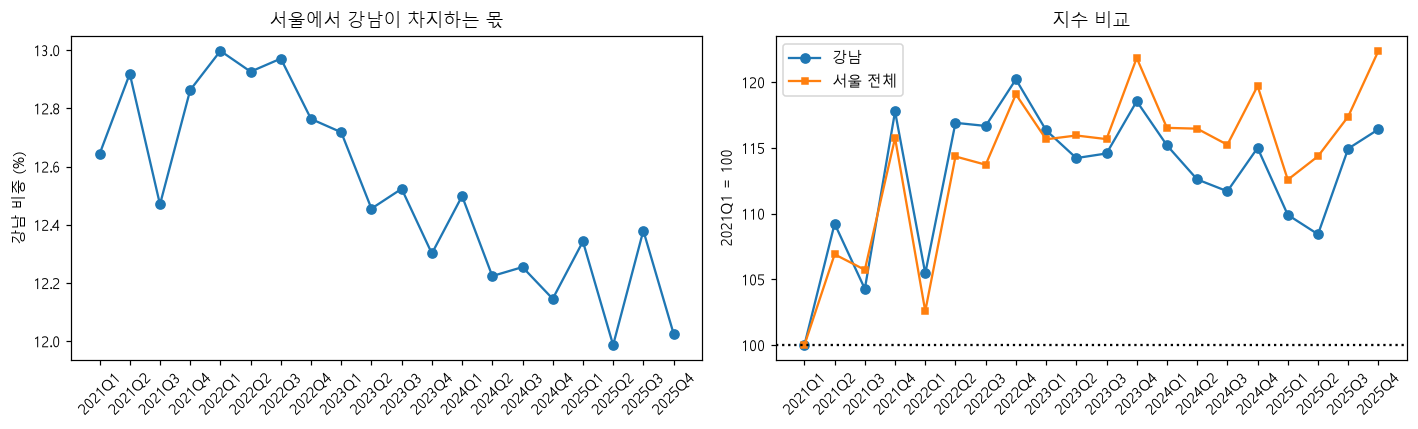

In [16]:
q서울 = sales.groupby(['year', 'quarter'])['당월_매출_금액'].sum() / 억
비중 = (q / q서울 * 100)
print('서울 분기 매출(조 원):', (q서울 / 10000).round(1).head(3).to_dict(), '...')
print('강남 비중(%): 2021Q1', round(비중.iloc[0], 1), '-> 2025Q4', round(비중.iloc[-1], 1),
      '| 2025Q3', round(비중.loc[(2025, 3)], 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
라벨 = [f'{y}Q{n}' for y, n in q.index]
axes[0].plot(라벨, 비중.values, marker='o', color=REGION_COLOR['강남'])
axes[0].set(ylabel='강남 비중 (%)', title='서울에서 강남이 차지하는 몫')
axes[1].plot(라벨, q.values / q.iloc[0] * 100, marker='o', label='강남')
axes[1].plot(라벨, q서울.values / q서울.iloc[0] * 100, marker='s', ms=4, label='서울 전체')
axes[1].axhline(100, ls=':', color='k'); axes[1].set(ylabel='2021Q1 = 100', title='지수 비교'); axes[1].legend()
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

### 4-3. 3분기는 원래 낮은 분기인가 (계절성)

강남: 분기 매출 / 그해 분기 평균


quarter,1,2,3,4
year,,,,
2021,0.927,1.013,0.967,1.092
2022,0.918,1.018,1.016,1.047
2023,1.004,0.985,0.988,1.023
2024,1.014,0.991,0.983,1.012
2025,0.978,0.964,1.022,1.035


서울 전체


quarter,1,2,3,4
year,,,,
2021,0.934,0.998,0.987,1.081
2022,0.912,1.017,1.011,1.059
2023,0.986,0.989,0.986,1.039
2024,0.996,0.996,0.985,1.023
2025,0.965,0.980,1.006,1.049


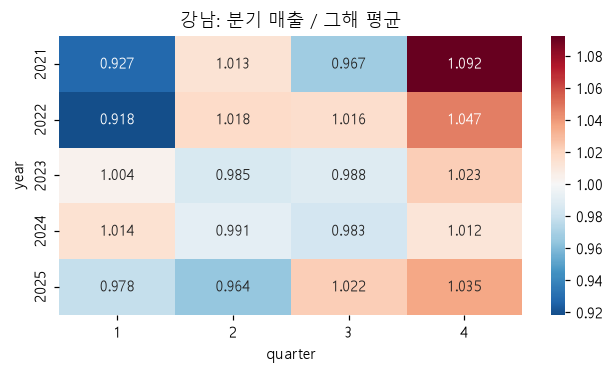

In [17]:
qt = q.unstack()
계절 = qt.div(qt.mean(axis=1), axis=0)
with pd.option_context('display.float_format', '{:.3f}'.format):
    print('강남: 분기 매출 / 그해 분기 평균'); display(계절)
    qt서울 = q서울.unstack()
    print('서울 전체'); display(qt서울.div(qt서울.mean(axis=1), axis=0))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(계절, annot=True, fmt='.3f', cmap='RdBu_r', center=1, ax=ax)
ax.set_title('강남: 분기 매출 / 그해 평균'); plt.tight_layout(); plt.show()

### 4-4. 전년 같은 분기 대비 증감률 (YoY)

강남 YoY(%)


quarter,1,2,3,4
year,,,,
2021,NaN,NaN,NaN,NaN
2022,5.4,7.0,11.9,2.1
2023,10.3,-2.3,-1.8,-1.4
2024,-1.0,-1.4,-2.5,-3.0
2025,-4.6,-3.7,2.9,1.2


서울 YoY(%)


quarter,1,2,3,4
year,,,,
2021,NaN,NaN,NaN,NaN
2022,2.6,7.0,7.6,2.9
2023,12.7,1.4,1.7,2.3
2024,0.8,0.4,-0.4,-1.8
2025,-3.4,-1.8,1.9,2.2


2025년 3분기 매출 순위: 10 / 20개 분기


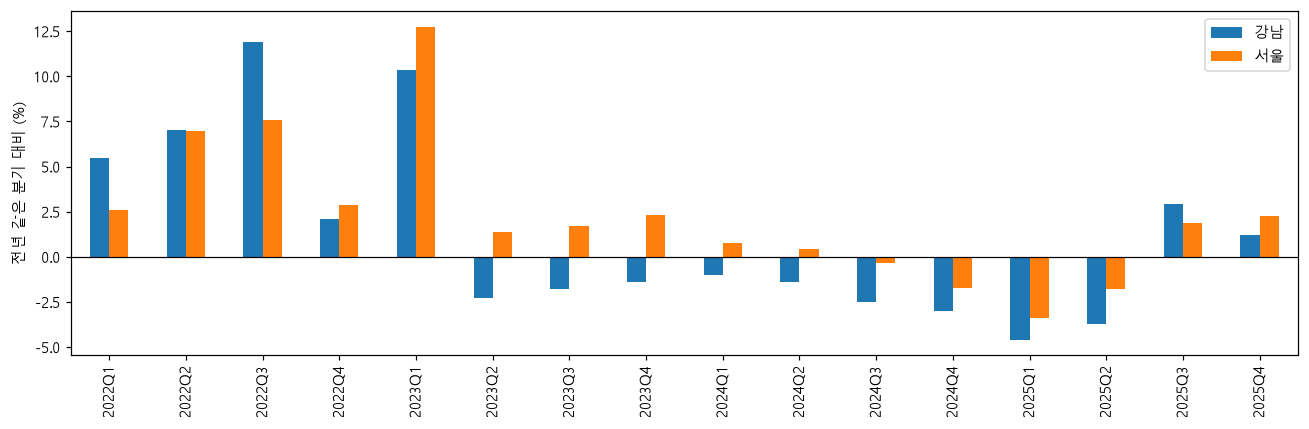

In [18]:
yoy = (qt / qt.shift(1) - 1) * 100
yoy서울 = (qt서울 / qt서울.shift(1) - 1) * 100
print('강남 YoY(%)'); display(yoy.round(1))
print('서울 YoY(%)'); display(yoy서울.round(1))
print('2025년 3분기 매출 순위:', int(q.rank(ascending=False)[(2025, 3)]), '/ 20개 분기')

t = pd.DataFrame({'강남': yoy.stack(), '서울': yoy서울.stack()}).dropna()
t.index = [f'{y}Q{n}' for y, n in t.index]
t.plot(kind='bar', figsize=(12, 4))
plt.axhline(0, color='k', lw=0.8); plt.ylabel('전년 같은 분기 대비 (%)')
plt.tight_layout(); plt.show()

### 4-5. 업종그룹별 장기 추세

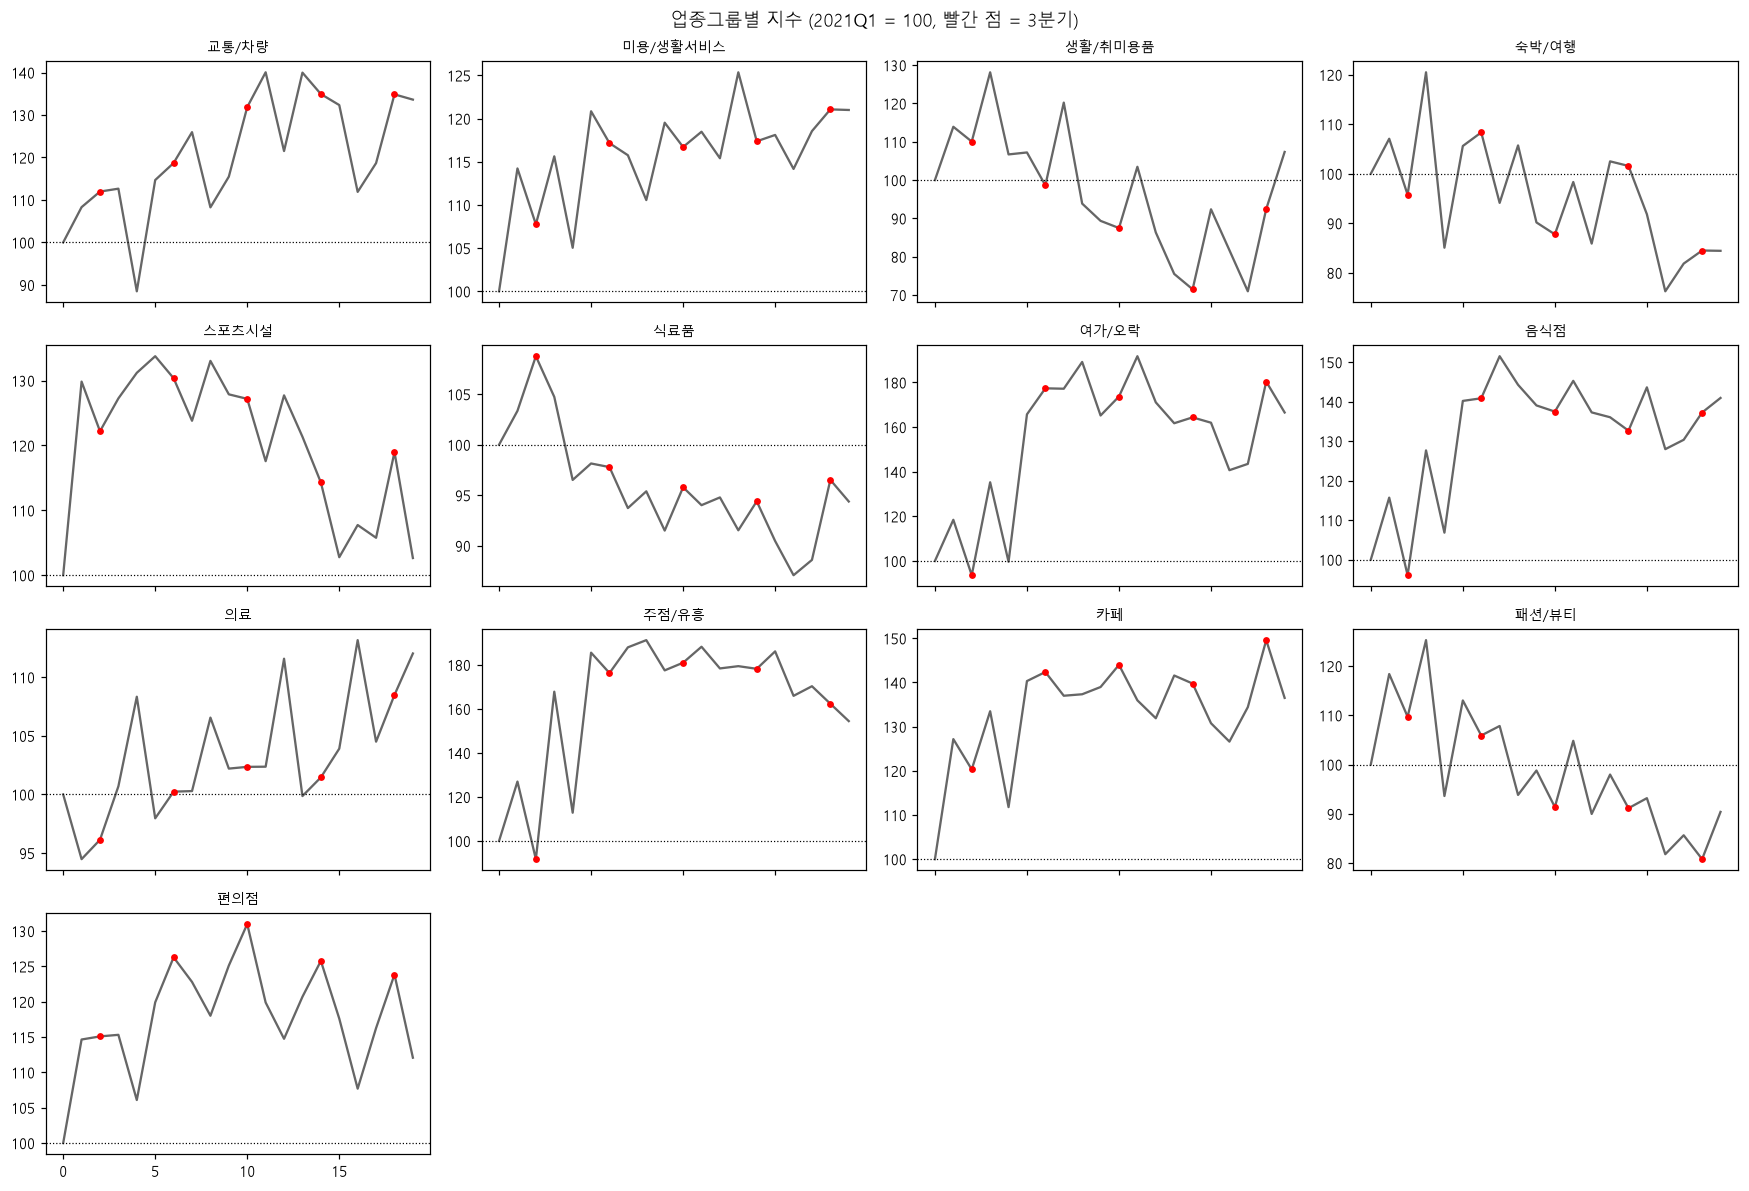

5년 변화(%)


group,여가/오락,주점/유흥,음식점,교통/차량,카페,의료,미용/생활서비스,편의점,스포츠시설,식료품,생활/취미용품,숙박/여행,패션/뷰티
0,41.0,34.0,22.0,15.0,14.0,12.0,8.0,3.0,-9.0,-12.0,-22.0,-23.0,-25.0


2025년 3분기 YoY(%)


group,생활/취미용품,여가/오락,카페,의료,스포츠시설,음식점,미용/생활서비스,식료품,교통/차량,편의점,주점/유흥,패션/뷰티,숙박/여행
0,29.3,9.7,7.0,6.9,4.1,3.5,3.1,2.2,-0.1,-1.5,-8.9,-11.4,-16.8


3분기 / 그해 평균


year,2021,2022,2023,2024,2025
group,,,,,
교통/차량,1.035,1.060,1.064,1.021,1.081
미용/생활서비스,0.985,1.021,1.003,0.986,1.020
생활/취미용품,0.974,0.912,0.935,0.878,1.049
숙박/여행,0.905,1.102,0.919,1.064,1.033
스포츠시설,1.020,1.005,1.006,0.981,1.094
식료품,1.044,1.013,1.017,1.017,1.053
여가/오락,0.837,1.145,0.965,0.997,1.143
음식점,0.874,1.045,0.972,0.965,1.023
의료,0.983,0.986,0.990,0.974,0.990


,2025Q3 매출(억),YoY(%),3분기/연평균 2025,3분기/연평균 2021~2024,차이
패션/뷰티,"3,891.644",-11.350,0.954,0.974,-0.019
의료,"7,809.319",6.935,0.990,0.983,0.007
미용/생활서비스,859.318,3.147,1.020,0.999,0.021
편의점,"1,561.417",-1.529,1.077,1.052,0.025
식료품,"1,684.205",2.249,1.053,1.023,0.030
강남 전체,"32,318.212",2.905,1.022,0.989,0.034
숙박/여행,38.788,-16.818,1.033,0.998,0.036
교통/차량,232.844,-0.058,1.081,1.045,0.036
주점/유흥,860.062,-8.903,0.994,0.947,0.048
음식점,"7,983.503",3.465,1.023,0.964,0.059


In [19]:
gnC = gn[gn['group'].ne('제외')]
g그룹 = gnC.groupby(['group', 'year', 'quarter'])['당월_매출_금액'].sum() / 억

그룹들 = sorted(gnC['group'].unique())
fig, axes = plt.subplots(4, 4, figsize=(16, 11), sharex=True)
for ax, gname in zip(axes.ravel(), 그룹들):
    s = g그룹.loc[gname]
    ax.plot(range(len(s)), s.values / s.iloc[0] * 100, color='0.4')
    q3 = [i for i, (y, n) in enumerate(s.index) if n == 3]
    ax.scatter(q3, (s.values / s.iloc[0] * 100)[q3], color='red', s=12, zorder=3)
    ax.axhline(100, ls=':', color='k', lw=0.8)
    ax.set_title(gname, fontsize=9)
for ax in axes.ravel()[len(그룹들):]:
    ax.axis('off')
fig.suptitle('업종그룹별 지수 (2021Q1 = 100, 빨간 점 = 3분기)')
plt.tight_layout(); plt.show()

연 = g그룹.groupby(['group', 'year']).sum().unstack()
변화 = ((연[2025] / 연[2021] - 1) * 100).sort_values(ascending=False)
print('5년 변화(%)'); display(변화.round(0).to_frame().T)

q3yoy = (g그룹.xs(3, level='quarter').unstack().pipe(lambda d: (d[2025] / d[2024] - 1) * 100)).sort_values(ascending=False)
print('2025년 3분기 YoY(%)'); display(q3yoy.round(1).to_frame().T)

계절그룹 = (g그룹.unstack('quarter').pipe(lambda d: d[3] / d.mean(axis=1))).unstack('year')
with pd.option_context('display.float_format', '{:.3f}'.format):
    print('3분기 / 그해 평균'); display(계절그룹)

요약 = pd.DataFrame({
    '2025Q3 매출(억)': g그룹.xs((2025, 3), level=('year', 'quarter')),
    'YoY(%)': q3yoy,
    '3분기/연평균 2025': 계절그룹[2025],
    '3분기/연평균 2021~2024': 계절그룹[[2021, 2022, 2023, 2024]].mean(axis=1)})
요약['차이'] = 요약['3분기/연평균 2025'] - 요약['3분기/연평균 2021~2024']
전체 = pd.DataFrame({'2025Q3 매출(억)': [q.loc[(2025, 3)]], 'YoY(%)': [yoy.loc[2025, 3]],
                     '3분기/연평균 2025': [계절.loc[2025, 3]],
                     '3분기/연평균 2021~2024': [계절.loc[2021:2024, 3].mean()]}, index=['강남 전체'])
전체['차이'] = 전체['3분기/연평균 2025'] - 전체['3분기/연평균 2021~2024']
with pd.option_context('display.float_format', '{:,.3f}'.format):
    display(pd.concat([전체, 요약]).sort_values('차이'))

### 4장 정리
- **본 것**: 강남 분기 추이(4-1), 서울과 비교(4-2), 계절성(4-3), YoY(4-4), 업종그룹별 추세(4-5)
- **나온 것**:
  - 강남 연 매출은 2023년 13.0조가 최고이고 이후 완만히 감소해 2025년 12.6조
  - 강남이 서울에서 차지하는 몫이 12.6% → 12.0%로 천천히 줄어든다. **2025년 3분기에 강남만 특별히 빠지지 않았다**
  - **3분기는 보통 연평균보다 1~2% 낮은 분기**(4년 중 3년)인데 **2025년 3분기는 1.022로 5년 중 가장 높다**
  - 6개 분기 연속 감소하던 강남 매출이 2025년 3분기에 **처음 증가로 돌아섰다**(YoY +2.9%). 서울 전체도 +1.9%
  - 5년 변화는 여가/오락 +41%, 주점/유흥 +34%, 음식점 +22% / 패션/뷰티 -25%, 숙박/여행 -23%
  - 2025년 3분기 계절 지수가 5년 중 가장 높은 그룹: **카페 1.094, 편의점 1.077, 여가/오락 1.143, 스포츠시설 1.094**
- **시사점**:
  - **분기 합계로는 폭염의 눌림이 보이지 않는다.** 며칠 단위 효과가 90일 합계에 묻히기 때문이다(05번에서 일 단위로 확인)
  - 카페와 편의점이 5년 중 가장 높은 3분기였다는 것은 **더위가 이 업종 소비를 늘렸을 가능성**을 시사한다. 07번에서도 커피전문점의 tmax 상관이 춘천 +0.66으로 가장 높았다
  - 평년보다 낮았던 유일한 그룹은 **패션/뷰티(0.954 vs 0.974)** 다. 05번에서 이 그룹의 폭염 반응을 특히 볼 것

## 5. 상가정보: 폐업과 신규
소상공인시장진흥공단의 상가 업소 목록 **2025년 10월, 12월 두 시점**을 비교한다.
- **폐업 추정** = 10월에만 있고 12월에 없는 업소번호 (10월 목록에서만 셀 수 있음)
- **신규** = 12월에만 있고 10월에 없는 업소번호 (12월 목록에서만 셀 수 있음)

> ⚠️ 두 시점이 **여름이 끝난 뒤 2개월 간격**이라 폭염 전후 비교가 아니다. "폭염 때문에 문을 닫았다"는 말은 이 자료로 할 수 없다.
> 폐업 지표는 소비가 줄어든 결과가 몇 달 뒤에 나타나는 **느린 공급 쪽 지표**라서, 이번 분석에서는 두 지역 상권의 기본 체력(가게가 얼마나 자주 바뀌는가)을 보는 용도이다.

### 5-1. 두 시점 비교 표 만들기

In [20]:
stores['key'] = stores['region'] + '|' + stores['상가업소번호']
id10 = set(stores.loc[stores['snapshot'].eq('202510'), 'key'])
id12 = set(stores.loc[stores['snapshot'].eq('202512'), 'key'])

stores['status'] = np.where(
    stores['snapshot'].eq('202510'),
    np.where(stores['key'].isin(id12), '유지', '폐업추정'),
    np.where(stores['key'].isin(id10), '유지', '신규'))

display(stores.pivot_table(index='region', columns='snapshot', values='key', aggfunc='size'))
상태표 = stores.pivot_table(index='region', columns='status', values='key', aggfunc='size')
상태표['유지'] = 상태표['유지'] // 2      # 유지 업소는 10월, 12월 양쪽에 있어서 두 번 세어진다
display(상태표)

# 두 시점에 모두 있는 업소에서 정보가 바뀐 곳이 있는가
유지 = stores[stores['status'].eq('유지')]
확인열 = ['상호명', '상권업종대분류명', '도로명주소', '행정동명']
바뀜 = (유지.groupby('key')[확인열].nunique() > 1).any(axis=1)
print(f'유지 업소 {유지["key"].nunique():,}개 중 정보가 바뀐 곳: {int(바뀜.sum())}개')

snapshot,202510,202512
region,,
강남,64146,64123
춘천,17497,17486


status,신규,유지,폐업추정
region,,,
강남,1386,62737,1409
춘천,423,17063,434


유지 업소 79,800개 중 정보가 바뀐 곳: 0개


### 5-2. 지역별 폐업률과 신규율

,10월,12월,폐업추정,신규,폐업률,신규율,순증감,순증감률
region,,,,,,,,
강남,64146,64123,1409,1386,2.2,2.2,-23,-0.0
춘천,17497,17486,434,423,2.5,2.4,-11,-0.1


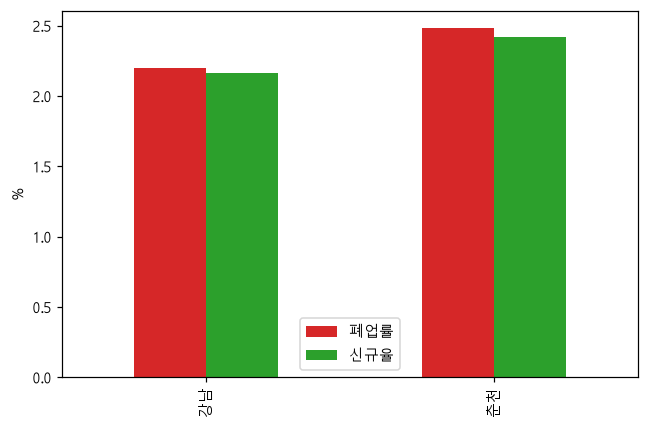

In [21]:
def rates(by=None):
    """지역(+추가 축)별 10월 수, 12월 수, 폐업추정, 신규, 폐업률, 신규율, 순증감을 돌려준다."""
    키 = ['region'] + (by or [])
    oct_ = stores[stores['snapshot'].eq('202510')].groupby(키).size().rename('10월')
    dec_ = stores[stores['snapshot'].eq('202512')].groupby(키).size().rename('12월')
    clo = stores[stores['status'].eq('폐업추정')].groupby(키).size().rename('폐업추정')
    new = stores[stores['status'].eq('신규')].groupby(키).size().rename('신규')
    t = pd.concat([oct_, dec_, clo, new], axis=1).fillna(0)
    t['폐업률'] = t['폐업추정'] / t['10월'] * 100
    t['신규율'] = t['신규'] / t['10월'] * 100
    t['순증감'] = t['12월'] - t['10월']
    t['순증감률'] = t['순증감'] / t['10월'] * 100
    return t


지역 = rates()
display(지역.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
지역[['폐업률', '신규율']].plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])
ax.set(ylabel='%', xlabel=''); plt.tight_layout(); plt.show()

### 5-3. 대분류별 폐업률과 신규율

10월    12월  폐업추정    신규  폐업률  신규율  순증감  순증감률
region 상권업종대분류명                                               
강남     과학/기술     18988  18854   265 131.0  1.4  0.7 -134  -0.7
       교육         6264   6219   153 108.0  2.4  1.7  -45  -0.7
       보건의료       3027   3067    34  74.0  1.1  2.4   40   1.3
       부동산        3731   3665    83  17.0  2.2  0.5  -66  -1.8
       소매         9789   9869   204 284.0  2.1  2.9   80   0.8
       수리/개인      4663   4681   103 121.0  2.2  2.6   18   0.4
       숙박          519    511    17   9.0  3.3  1.7   -8  -1.5
       시설관리/임대    3172   3132    50  10.0  1.6  0.3  -40  -1.3
       예술/스포츠     1757   1779    52  74.0  3.0  4.2   22   1.2
       음식        12236  12346   448 558.0  3.7  4.6  110   0.9
춘천     과학/기술      1321   1323     9  11.0  0.7  0.8    2   0.1
       교육         1311   1299    35  23.0  2.7  1.8  -12  -0.9
       보건의료        383    383     3   3.0  0.8  0.8    0   0.0
       부동산         483    477     6   0.0  1.2  0.0   -6  -1.2
       소매         3974   3998    98 122.0  2.5  3.1   24   0.6
       수리/개인      2120   2118    35  33.0  1.6  1.6   -2  -0.1
       숙박          767    756    21  10.0  2.7  1.3  -11  -1.4
       시설관리/임대     688    675    13   0.0  1.9  0.0  -13  -1.9
       예술/스포츠      777    786    18  27.0  2.3  3.5    9   1.2
       음식         5673   5671   196 194.0  3.5  3.4   -2  -0.0

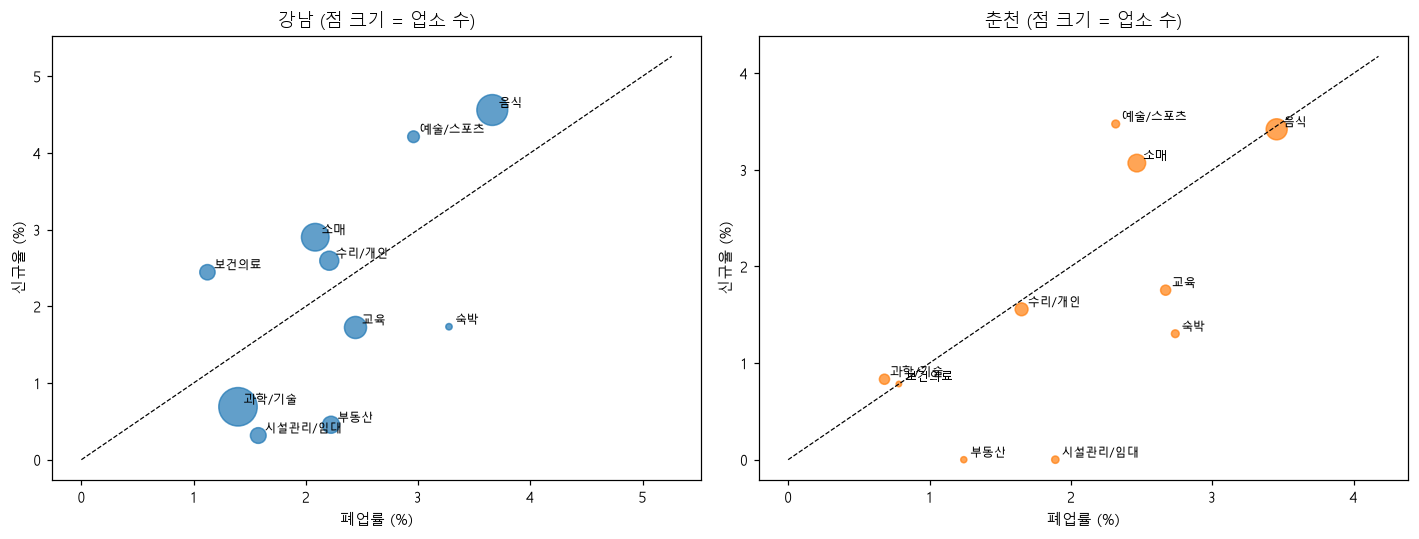

In [22]:
대분류 = rates(['상권업종대분류명'])
display(대분류.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, ['강남', '춘천']):
    t = 대분류.loc[r]
    ax.scatter(t['폐업률'], t['신규율'], s=t['10월'] / 30, color=REGION_COLOR[r], alpha=0.7)
    for name in t.index:
        ax.annotate(name, (t.loc[name, '폐업률'], t.loc[name, '신규율']), fontsize=8,
                    xytext=(4, 2), textcoords='offset points')
    lim = [0, max(t['폐업률'].max(), t['신규율'].max()) + 0.7]
    ax.plot(lim, lim, 'k--', lw=0.8)
    ax.set(xlabel='폐업률 (%)', ylabel='신규율 (%)', title=f'{r} (점 크기 = 업소 수)')
plt.tight_layout(); plt.show()

### 5-4. 중분류별 폐업률과 신규율

강남 폐업률 상위 5


,10월,폐업률,신규율
상권업종중분류명,,,
주점,1171,4.9,1.4
비알코올,2113,4.2,2.8
기타 간이,1989,4.0,3.4
유원지/오락,501,4.0,2.8
서양식,1022,3.8,6.1


강남 신규율 상위 5


,10월,폐업률,신규율
상권업종중분류명,,,
기타 상품 소매,239,1.3,15.5
한식,4317,3.2,6.6
기타 생활용품 소매,228,2.2,6.6
서양식,1022,3.8,6.1
스포츠 서비스,979,2.4,5.4


춘천 폐업률 상위 5


,10월,폐업률,신규율
상권업종중분류명,,,
주점,594,4.5,2.2
비알코올,825,3.8,1.7
종합 소매,785,3.7,2.2
의약/화장품 소매,309,3.6,2.3
한식,2667,3.4,4.7


춘천 신규율 상위 5


,10월,폐업률,신규율
상권업종중분류명,,,
한식,2667,3.4,4.7
스포츠 서비스,336,3.0,4.2
일반 교육,489,2.7,3.7
유원지/오락,376,1.6,3.5
식료품 소매,473,3.0,3.0


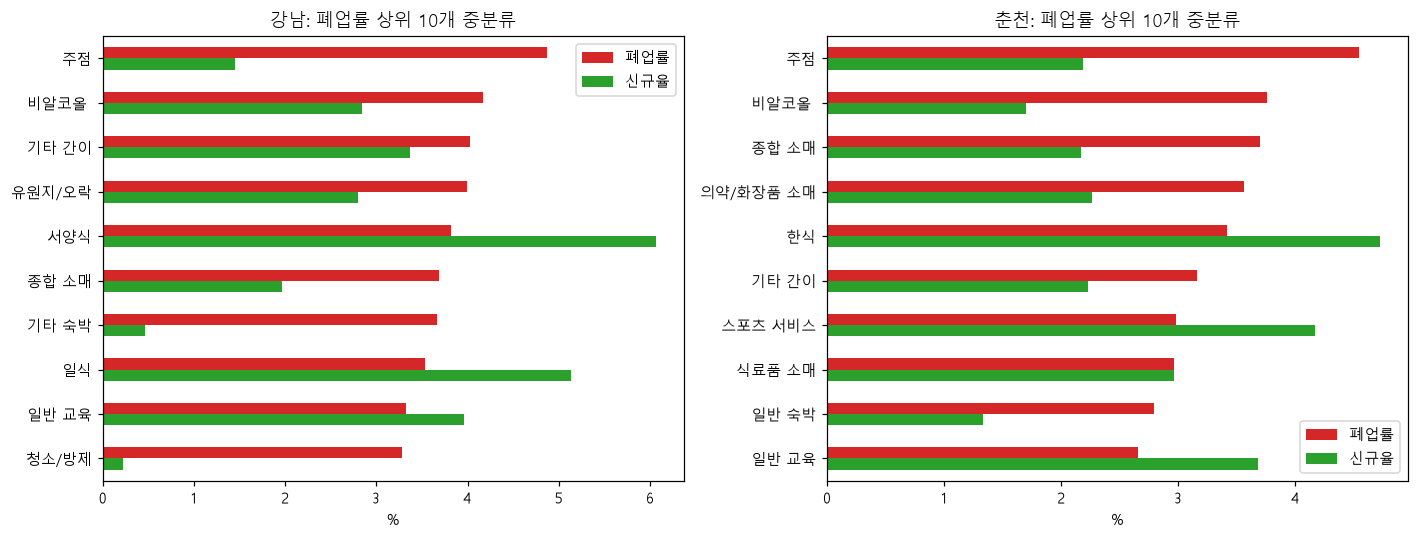

In [23]:
중분류 = rates(['상권업종중분류명'])
중분류 = 중분류[중분류['10월'] >= 200]

for r in ['강남', '춘천']:
    t = 중분류.loc[r]
    print(f'{r} 폐업률 상위 5'); display(t.nlargest(5, '폐업률')[['10월', '폐업률', '신규율']].round(2))
    print(f'{r} 신규율 상위 5'); display(t.nlargest(5, '신규율')[['10월', '폐업률', '신규율']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, ['강남', '춘천']):
    t = 중분류.loc[r].nlargest(10, '폐업률')[['폐업률', '신규율']]
    t.plot(kind='barh', ax=ax, color=['#d62728', '#2ca02c'])
    ax.set(title=f'{r}: 폐업률 상위 10개 중분류', xlabel='%', ylabel='')
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

### 5-5. 업소번호 재발급 점검

In [24]:
폐업 = stores[stores['status'].eq('폐업추정')]
신규 = stores[stores['status'].eq('신규')]

for 키열, 이름 in [(['region', '상호명', '도로명주소'], '상호명 + 주소'),
                   (['region', '상호명', '도로명주소', '층정보'], '층까지')]:
    겹침 = 폐업.merge(신규, on=키열, how='inner')
    t = 겹침.groupby('region').size()
    print(f'재발급 의심 ({이름}):', t.to_dict(),
          '| 폐업추정 대비', {r: f'{v / len(폐업[폐업["region"].eq(r)]):.1%}' for r, v in t.items()})

print('\n업소번호 예:', stores['상가업소번호'].iat[0], '| 길이', stores['상가업소번호'].str.len().unique())
for 이름, d in [('신규', 신규), ('폐업추정', 폐업)]:
    연도 = d['상가업소번호'].str[6:10].value_counts()
    print(f'{이름} {len(d):,}개의 번호 연도:', 연도.head(5).to_dict())

재발급 의심 (상호명 + 주소): {'강남': 48, '춘천': 28} | 폐업추정 대비 {'강남': '3.4%', '춘천': '6.5%'}


재발급 의심 (층까지): {'강남': 9, '춘천': 10} | 폐업추정 대비 {'강남': '0.6%', '춘천': '2.3%'}

업소번호 예: MA010120220812109029 | 길이 [20]
신규 1,809개의 번호 연도: {'2025': 1667, '2022': 119, '2024': 13, '2023': 10}
폐업추정 1,843개의 번호 연도: {'2022': 1007, '2024': 486, '2023': 205, '2025': 145}


### 5장 정리
- **본 것**: 두 시점 비교표(5-1), 지역별(5-2), 대분류(5-3), 중분류(5-4), 번호 재발급 점검(5-5)
- **나온 것**:
  - 2개월 동안 강남 폐업률 2.20% 신규율 2.16%, 춘천 2.48% / 2.42%. **사라진 만큼 새로 생겨 총수는 거의 그대로**(강남 -23개, 춘천 -11개)
  - 대분류에서는 **음식업이 가장 자주 바뀐다**(두 지역 모두 3.5% 안팎)
  - 중분류에서는 **주점과 비알코올(카페)** 이 폐업은 많고 신규는 적어 순감소한다(강남 주점 4.87% vs 1.45%)
  - 번호 재발급 의심이 폐업추정의 3.4%(강남), 6.5%(춘천)다. 신규 1,809개 중 119개는 번호 연도가 2022년이다
- **시사점**:
  - **폐업률의 절댓값은 믿을 수 없다.** 번호 재발급과 목록 누락으로 수%p 부풀려져 있다. 업종 사이, 동 사이 **상대 비교로만** 쓴다
  - 주점과 카페가 순감소한다는 점은 카드의 주점/유흥, 카페 그룹 해석에 참고가 된다

## 6. 상가정보: 행정동과 지도
상가정보의 `행정동코드`는 `dong_codes`의 `adm_cd8_mois`와 같은 체계라서 행정동 경계 지도에 바로 붙는다.
업소마다 경도, 위도도 있어서 점으로 찍을 수도 있다.

### 6-1. 행정동별 폐업률과 신규율

In [25]:
동별 = rates(['행정동코드']).reset_index()
동별 = 동별.merge(dong_codes[['adm_cd8_mois', 'dong']], left_on='행정동코드', right_on='adm_cd8_mois', how='left')
print('못 붙은 동:', int(동별['dong'].isna().sum()), '| 동 수:', 동별.groupby('region')['dong'].nunique().to_dict())

for r in ['강남', '춘천']:
    t = 동별[동별['region'].eq(r)].set_index('dong')
    print(f'{r} 폐업률 상위 5'); display(t.nlargest(5, '폐업률')[['10월', '폐업률', '신규율']].round(2))
    print(f'{r} 폐업률 하위 3'); display(t.nsmallest(3, '폐업률')[['10월', '폐업률', '신규율']].round(2))
    print(f"   가장 작은 동의 업소 수 {int(t['10월'].min())} | 폐업률-신규율 상관 {t['폐업률'].corr(t['신규율']):.2f}")

못 붙은 동: 0 | 동 수: {'강남': 22, '춘천': 25}
강남 폐업률 상위 5


,10월,폐업률,신규율
dong,,,
개포3동,339,3.8,0.9
개포1동,137,2.9,0.0
개포2동,851,2.8,2.4
대치1동,941,2.8,2.2
일원1동,769,2.7,1.8


강남 폐업률 하위 3


,10월,폐업률,신규율
dong,,,
일원본동,335,0.9,1.5
도곡2동,1184,1.4,2.0
수서동,901,1.6,1.6


   가장 작은 동의 업소 수 137 | 폐업률-신규율 상관 -0.25
춘천 폐업률 상위 5


,10월,폐업률,신규율
dong,,,
교동,291,3.8,1.7
효자1동,199,3.5,1.0
효자3동,747,3.5,3.4
퇴계동,2144,3.1,2.1
석사동,2021,3.1,2.3


춘천 폐업률 하위 3


,10월,폐업률,신규율
dong,,,
사북면,117,0.0,1.7
남면,122,0.8,0.8
신동면,198,1.0,3.0


   가장 작은 동의 업소 수 42 | 폐업률-신규율 상관 -0.04


### 6-2. 행정동 지도 (단계구분도)

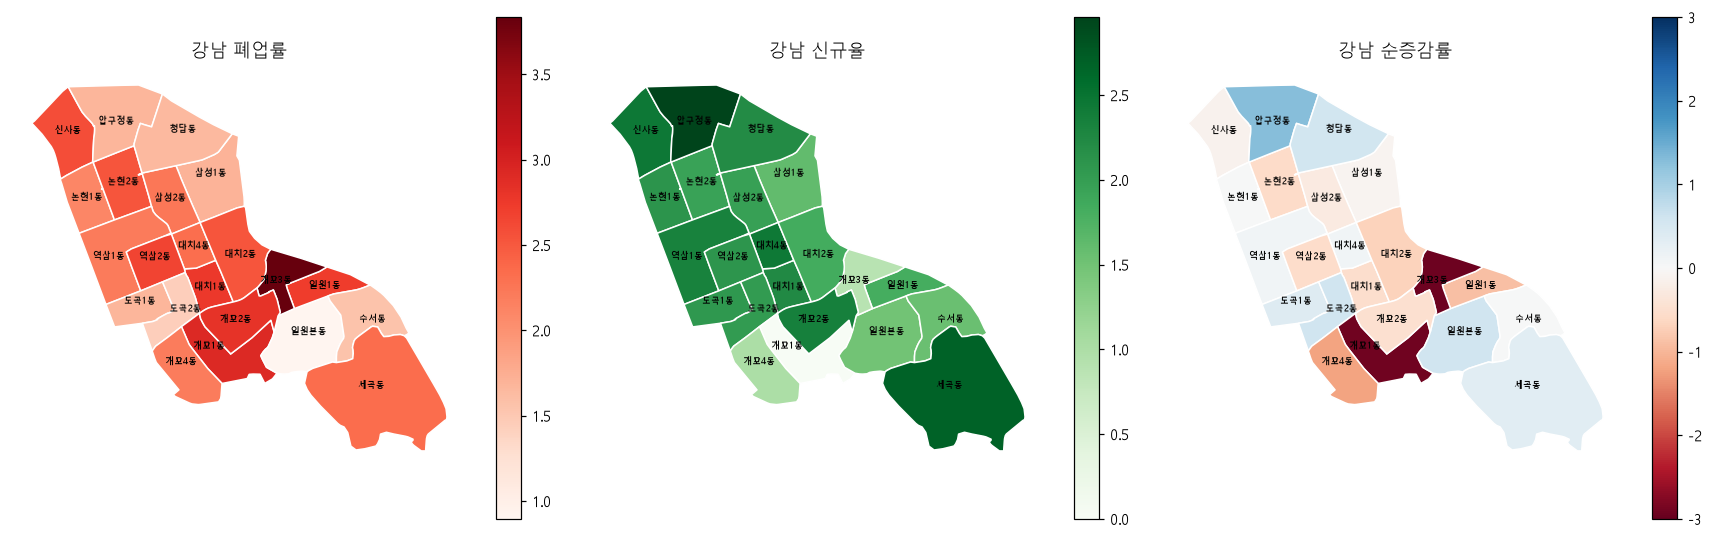

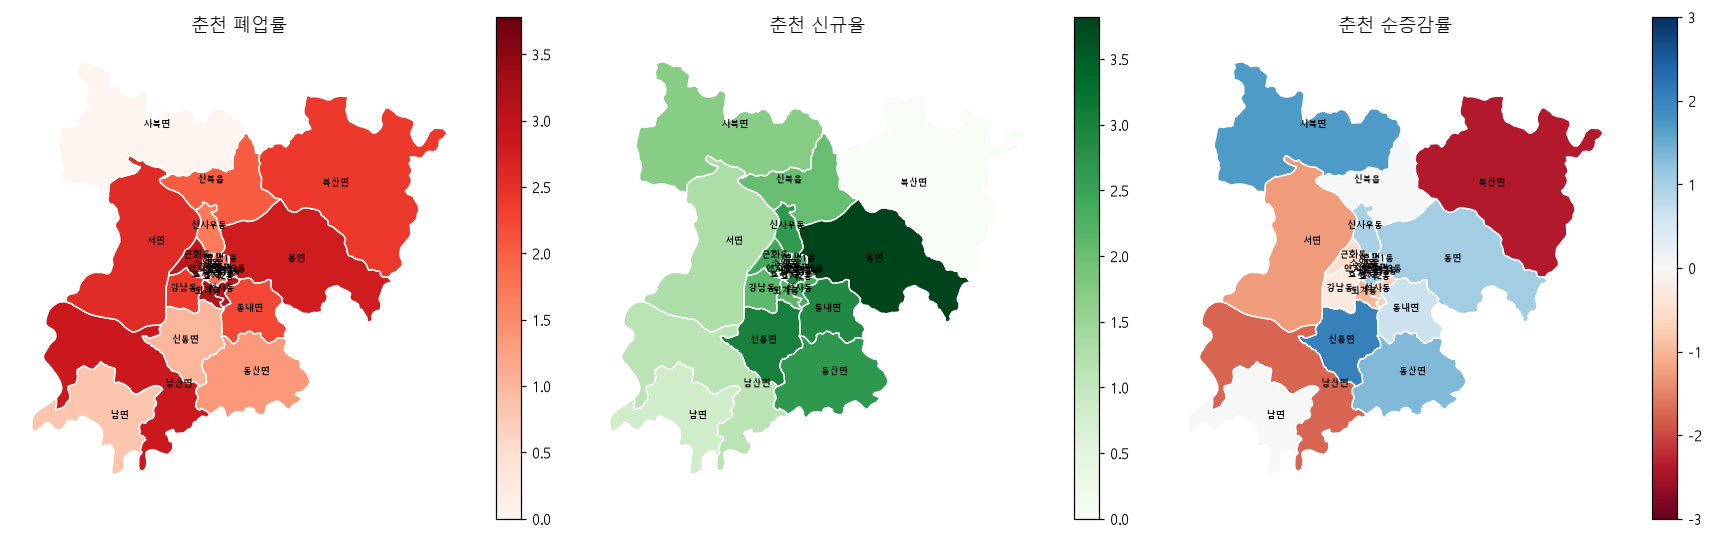

In [26]:
gdf = dong_gdf.copy()
gdf['adm_cd8_mois'] = gdf['adm_cd8_mois'].astype(str)
gdf = gdf.merge(동별[['행정동코드', 'region', '폐업률', '신규율', '순증감률', '10월']],
                left_on=['adm_cd8_mois', 'region'], right_on=['행정동코드', 'region'], how='left')

for r in ['강남', '춘천']:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    g = gdf[gdf['region'].eq(r)]
    for ax, col, cmap, kw in [(axes[0], '폐업률', 'Reds', {}), (axes[1], '신규율', 'Greens', {}),
                              (axes[2], '순증감률', 'RdBu', {'vmin': -3, 'vmax': 3})]:
        g.plot(column=col, cmap=cmap, legend=True, edgecolor='white', ax=ax, **kw)
        for _, row in g.iterrows():
            p = row['geometry'].representative_point()
            ax.annotate(row['dong'], (p.x, p.y), fontsize=6, ha='center')
        ax.set(title=f'{r} {col}'); ax.axis('off')
    plt.tight_layout(); plt.show()

### 6-3. 업소 위치 점 지도

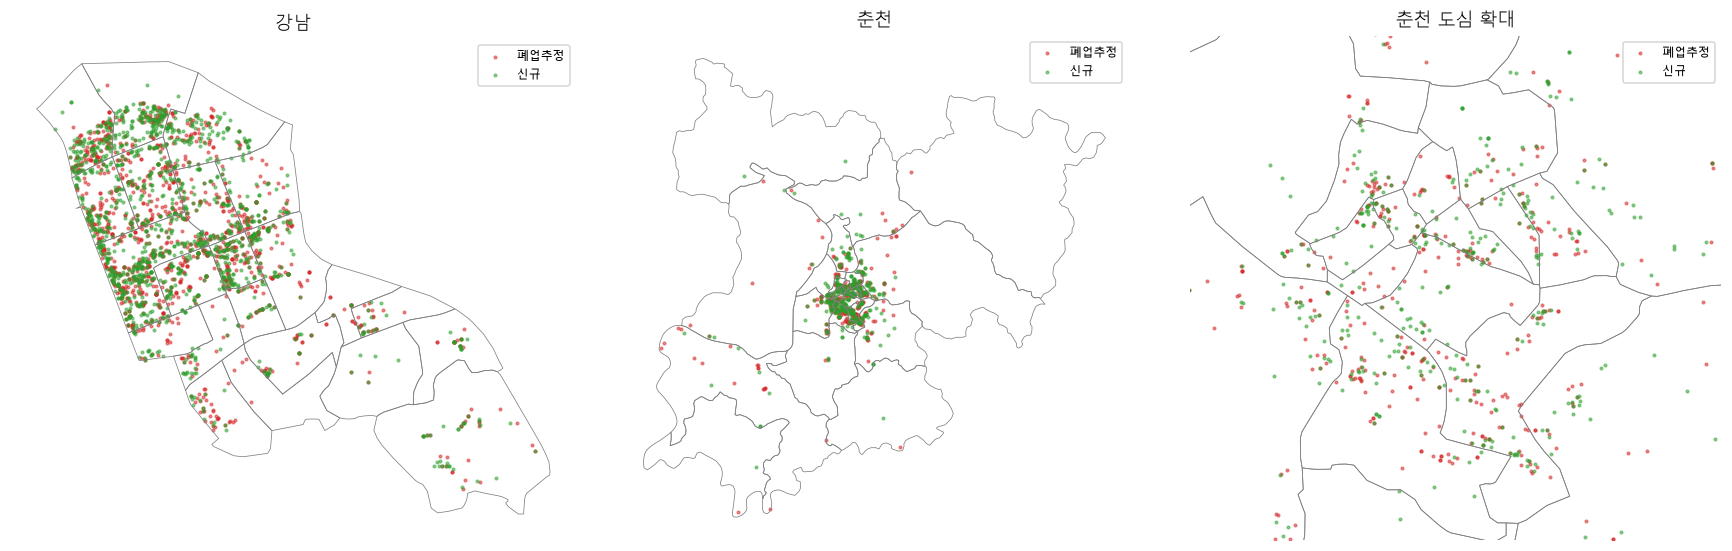

강남 좌표 범위: 경도 127.02~127.12, 위도 37.46~37.53
춘천 좌표 범위: 경도 127.51~127.95, 위도 37.68~38.05


10월 업소 중 적힌 행정동과 좌표가 같은 동에 떨어지는 비율: 99.1%


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
범위 = {'강남': None, '춘천': (127.70, 127.78, 37.84, 37.90)}
for ax, (r, zoom) in zip(axes, [('강남', None), ('춘천', None), ('춘천', 범위['춘천'])]):
    g = dong_gdf[dong_gdf['region'].eq(r)]
    g.boundary.plot(color='gray', linewidth=0.5, ax=ax)
    for 상태, 색 in [('폐업추정', '#d62728'), ('신규', '#2ca02c')]:
        d = stores[stores['region'].eq(r) & stores['status'].eq(상태)]
        ax.scatter(d['경도'], d['위도'], s=3, alpha=0.5, color=색, label=상태)
    if zoom:
        ax.set_xlim(zoom[0], zoom[1]); ax.set_ylim(zoom[2], zoom[3])
    ax.set(title=f'{r}{" 도심 확대" if zoom else ""}'); ax.legend(fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

for r in ['강남', '춘천']:
    d = stores[stores['region'].eq(r)]
    print(f"{r} 좌표 범위: 경도 {d['경도'].min():.2f}~{d['경도'].max():.2f}, 위도 {d['위도'].min():.2f}~{d['위도'].max():.2f}")

# 적힌 행정동과 실제 좌표가 떨어지는 동이 같은가
oct_ = stores[stores['snapshot'].eq('202510')]
pts = gpd.GeoDataFrame(oct_, geometry=gpd.points_from_xy(oct_['경도'], oct_['위도']), crs='EPSG:4326')
j = gpd.sjoin(pts, dong_gdf[['adm_cd8_mois', 'geometry']], predicate='within', how='left')
일치 = (j['행정동코드'] == j['adm_cd8_mois']).mean()
print(f'10월 업소 중 적힌 행정동과 좌표가 같은 동에 떨어지는 비율: {일치:.1%}')

### 6-4. 공급 쪽 회복 지표 아이디어

In [28]:
날씨민감 = ['음식']
t = 대분류.reset_index()
print('음식 대분류 순증감률(%):',
      t[t['상권업종대분류명'].isin(날씨민감)].set_index('region')['순증감률'].round(2).to_dict())

중 = 중분류.reset_index()
관심 = ['주점', '비알코올', '한식']
display(중[중['상권업종중분류명'].str.contains('|'.join(관심))]
        .set_index(['region', '상권업종중분류명'])[['10월', '폐업률', '신규율', '순증감률']].round(2))

동음식 = rates(['행정동코드', '상권업종대분류명']).reset_index()
동음식 = 동음식[동음식['상권업종대분류명'].eq('음식') & (동음식['10월'] >= 100)]
동음식 = 동음식.merge(dong_codes[['adm_cd8_mois', 'dong']], left_on='행정동코드', right_on='adm_cd8_mois')
for r in ['강남', '춘천']:
    print(f'{r}: 음식업 순증감률 하위 3개 동')
    display(동음식[동음식['region'].eq(r)].nsmallest(3, '순증감률').set_index('dong')[['10월', '폐업률', '신규율', '순증감률']].round(2))

음식 대분류 순증감률(%): {'강남': 0.9, '춘천': -0.04}


10월  폐업률  신규율  순증감률
region 상권업종중분류명                      
강남     비알코올      2113  4.2  2.8  -1.3
       주점        1171  4.9  1.4  -3.4
       한식        4317  3.2  6.6   3.5
춘천     비알코올       825  3.8  1.7  -2.1
       주점         594  4.5  2.2  -2.4
       한식        2667  3.4  4.7   1.3

강남: 음식업 순증감률 하위 3개 동


,10월,폐업률,신규율,순증감률
dong,,,,
대치1동,129,6.2,3.1,-3.1
개포4동,227,5.3,3.1,-2.2
일원1동,179,5.6,3.9,-1.7


춘천: 음식업 순증감률 하위 3개 동


,10월,폐업률,신규율,순증감률
dong,,,,
교동,102,5.9,2.0,-3.9
서면,105,4.8,1.9,-2.9
남산면,172,3.5,1.7,-1.7


**결정**: 상가정보를 이번 분석에서 어떻게 쓸지 적어 둔다.

- **결정**: **보고서 배경에 "두 지역 상권 교체율" 비교로만 쓰고 회복 지표로는 쓰지 않는다.**
  다만 폐업 자체를 보려면 상가정보가 아니라 **개폐업 원장(`bizreg`)** 을 쓴다.
- **이유**: 10월과 12월 두 시점뿐이라 "떨어졌다가 돌아오는" 회복을 볼 수 없고, 폭염이 끝난 뒤 구간이라 폭염 전후 비교도 아니다.
  번호 재발급 탓에 절댓값도 흔들린다. 반면 개폐업 원장은 폐업일자가 날짜로 찍혀 있어 **2021년부터의 월별 폐업 건수**를 만들 수 있다.

### 6장 정리
- **본 것**: 행정동별 폐업률과 신규율(6-1), 지도(6-2), 점 지도(6-3), 공급 쪽 지표 검토(6-4)
- **나온 것**:
  - 강남 22개 동, 춘천 25개 동 모두 경계 지도에 붙는다. 좌표와 적힌 행정동이 같은 비율은 **99.1%**
  - 강남 폐업률 상위는 **개포3동 3.8%, 개포1동 2.9%, 개포2동 2.8%** 로 개포동 일대에 몰린다. 하위는 일원본동 0.9%
  - 춘천은 교동 3.8%, 효자1동 3.5% 로 도심 쪽이 높고 사북면은 0%(업소 117개)
  - 동별 폐업률과 신규율의 상관은 강남 -0.25, 춘천 -0.04로 **폐업이 많은 동에 신규가 많지는 않다**
- **시사점**:
  - 강남 개포동 일대의 폐업 집중은 **재건축 등 도시 개발**로 보이며 날씨와 무관하다. 날씨 분석에서 지역 차이를 볼 때 이 점을 빼고 봐야 한다
  - > [추론] 춘천 부동산과 시설관리/임대 대분류는 신규가 0개다. 실제로 안 생겼다기보다 이 분류의 목록 갱신이 늦은 것으로 보인다
  - 면 지역은 넓어서 지도에서 크게 보이지만 업소가 100개 안팎이다. **색만 보고 판단하면 안 된다**

## 7. 관광 방문자 (내국인)
한국관광 데이터랩의 **월별 방문자 수**이다(2021~2025). 통신 데이터로 추정한 값이라 사람 수보다 "방문 횟수"에 가깝다.
- **현지인** = 그 **시군구**(강남구, 춘천시)에 사는 사람, **외지인** = 다른 시군구에서 온 사람
- 카드 데이터2의 외지인은 **시도** 기준(강남은 서울 밖, 춘천은 강원 밖)이라서 정의가 다르다. 8장에서 맞춘다.

### 7-1. 월별 방문자 수 추이 (2021~2025)

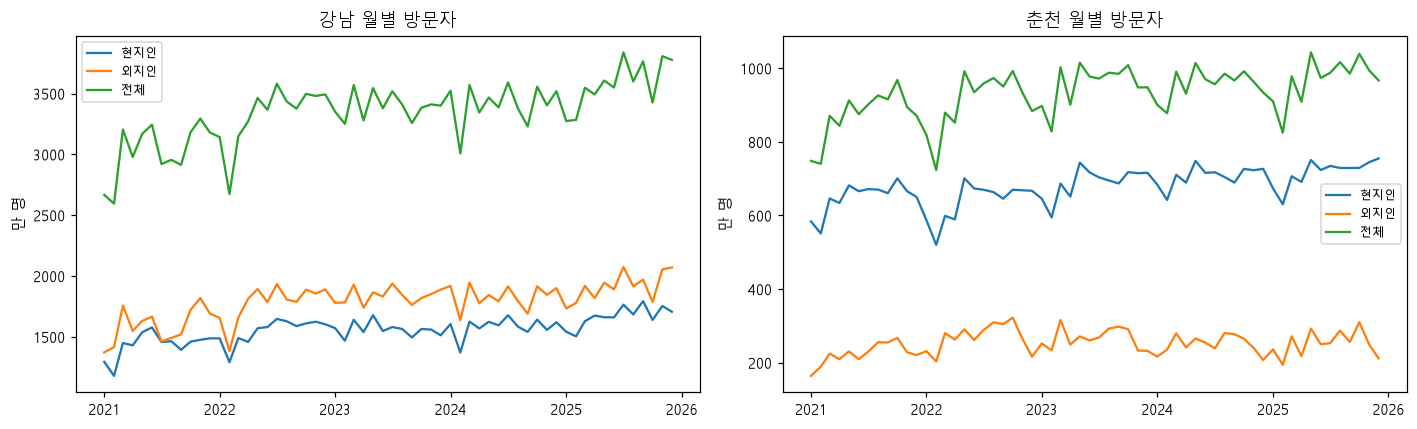

visitor_type      현지인      외지인       전체  외지인 비중(%)
region year                                       
강남     2021  17,206.2 19,096.4 36,302.6       52.6
       2022  18,578.9 21,350.5 39,929.4       53.5
       2023  18,721.6 22,032.9 40,754.5       54.1
       2024  19,007.6 21,972.2 40,979.8       53.6
       2025  20,010.4 22,955.6 42,966.1       53.4
춘천     2021   7,782.7  2,685.0 10,467.7       25.7
       2022   7,654.9  3,237.4 10,892.3       29.7
       2023   8,273.5  3,198.0 11,471.4       27.9
       2024   8,477.7  3,004.1 11,481.8       26.2
       2025   8,597.8  3,031.8 11,629.6       26.1

월평균(만 명): {'강남': 3349.0, '춘천': 932.0}


In [29]:
trend = tour['tour_dom_trend'].pivot_table(index=['region', 'month'], columns='visitor_type', values='visitors')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, ['강남', '춘천']):
    t = trend.loc[r] / 1e4
    for col in ['현지인', '외지인', '전체']:
        ax.plot(t.index, t[col], label=col)
    ax.set(ylabel='만 명', title=f'{r} 월별 방문자'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

연 = trend.reset_index()
연['year'] = 연['month'].dt.year
t = 연.groupby(['region', 'year'])[['현지인', '외지인', '전체']].sum() / 1e4
t['외지인 비중(%)'] = t['외지인'] / t['전체'] * 100
display(t.round(1))
print('월평균(만 명):', (trend['전체'].groupby(level='region').mean() / 1e4).round(0).to_dict())

### 7-2. 계절성 (몇 월에 많이 오나)

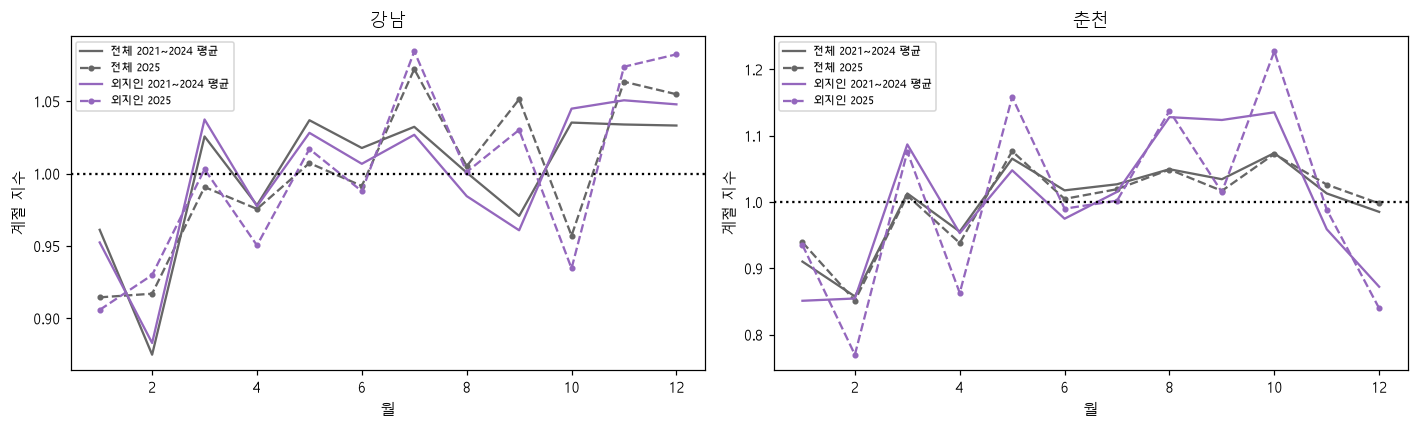

mon           1    2    3    4    5    6    7    8    9    10   11   12
region year                                                            
강남     2021 0.86 0.89 1.10 0.97 1.02 1.05 0.92 0.94 0.96 1.08 1.14 1.06
       2022 0.93 0.78 0.93 1.02 1.06 1.00 1.09 1.02 1.00 1.06 1.04 1.06
       2023 0.97 0.97 1.05 0.95 1.02 1.00 1.06 1.01 0.96 0.99 1.01 1.03
       2024 1.05 0.89 1.06 0.97 1.01 0.98 1.05 0.98 0.92 1.05 1.01 1.04
       2025 0.91 0.93 1.00 0.95 1.02 0.99 1.08 1.00 1.03 0.93 1.07 1.08
춘천     2021 0.73 0.85 1.00 0.94 1.03 0.94 1.03 1.14 1.14 1.19 1.02 0.99
       2022 0.86 0.75 1.04 0.97 1.08 0.97 1.07 1.15 1.13 1.19 0.98 0.80
       2023 0.95 0.88 1.19 0.94 1.02 0.98 1.01 1.10 1.12 1.09 0.87 0.87
       2024 0.87 0.94 1.12 0.96 1.06 1.02 0.95 1.12 1.11 1.06 0.96 0.83
       2025 0.94 0.77 1.08 0.86 1.16 0.99 1.00 1.14 1.01 1.23 0.99 0.84

In [30]:
계절 = trend.copy()
계절['year'] = 계절.index.get_level_values('month').year
계절['mon'] = 계절.index.get_level_values('month').month
for col in ['전체', '외지인']:
    계절[f'{col}_지수'] = 계절.groupby(['region', 'year'])[col].transform(lambda s: s / s.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, ['강남', '춘천']):
    t = 계절.loc[r]
    for col, 색 in [('전체_지수', '0.4'), ('외지인_지수', SOURCE_COLOR['관광'])]:
        평년 = t[t['year'] < 2025].groupby('mon')[col].mean()
        ax.plot(평년.index, 평년, color=색, label=f'{col[:-3]} 2021~2024 평균')
        올해 = t[t['year'] == 2025].groupby('mon')[col].mean()
        ax.plot(올해.index, 올해, color=색, ls='--', marker='o', ms=3, label=f'{col[:-3]} 2025')
    ax.axhline(1, ls=':', color='k'); ax.set(xlabel='월', ylabel='계절 지수', title=r); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

with pd.option_context('display.float_format', '{:.2f}'.format):
    display(계절.pivot_table(index=['region', 'year'], columns='mon', values='외지인_지수'))

### 7-3. 2025년 하반기 자세히 보기

visitor_type     현지인     외지인      전체
region mon                          
강남     7     1,764.0 2,074.0 3,839.0
       8     1,684.0 1,915.0 3,599.0
       9     1,794.0 1,971.0 3,764.0
       10    1,639.0 1,788.0 3,427.0
       11    1,754.0 2,054.0 3,808.0
       12    1,706.0 2,070.0 3,777.0
춘천     7       735.0   253.0   988.0
       8       729.0   287.0 1,016.0
       9       729.0   256.0   985.0
       10      729.0   310.0 1,039.0
       11      745.0   250.0   994.0
       12      755.0   212.0   967.0

전년 같은 달 대비(%)


visitor_type  외지인   전체
region mon            
강남     7      8.4  6.9
       8      6.7  6.5
       9     16.6 16.5
       10    -6.7 -3.7
       11    11.3 11.9
       12     9.0  7.3
춘천     7      5.9  3.3
       8      2.3  3.2
       9     -7.6  1.9
       10    16.9  4.8
       11     4.0  3.3
       12     2.4  3.5

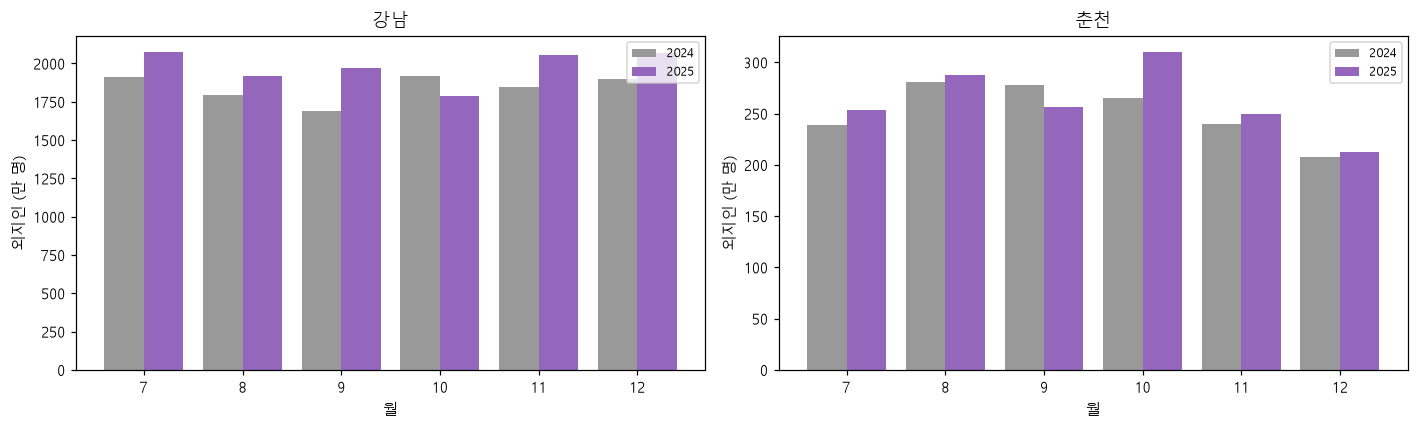

In [31]:
h = trend.reset_index()
h['year'], h['mon'] = h['month'].dt.year, h['month'].dt.month
h25 = h[(h['year'] == 2025) & h['mon'].between(7, 12)]
h24 = h[(h['year'] == 2024) & h['mon'].between(7, 12)]

t = h25.set_index(['region', 'mon'])[['현지인', '외지인', '전체']] / 1e4
display(t.round(0))

yoy = (h25.set_index(['region', 'mon'])[['외지인', '전체']]
       / h24.set_index(['region', 'mon'])[['외지인', '전체']] - 1) * 100
print('전년 같은 달 대비(%)'); display(yoy.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, ['강남', '춘천']):
    a = h24[h24['region'].eq(r)].set_index('mon')['외지인'] / 1e4
    b = h25[h25['region'].eq(r)].set_index('mon')['외지인'] / 1e4
    ax.bar(a.index - 0.2, a, width=0.4, label='2024', color='0.6')
    ax.bar(b.index + 0.2, b, width=0.4, label='2025', color=SOURCE_COLOR['관광'])
    ax.set(xlabel='월', ylabel='외지인 (만 명)', title=r); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 7-4. 외지인은 어디서 오나 (거주지)

연도별 비율 합계(%):


year,2021,2022,2023,2024,2025
region,,,,,
강남,98.6,98.8,98.9,98.8,98.3
춘천,98.2,99.6,99.5,99.7,99.2


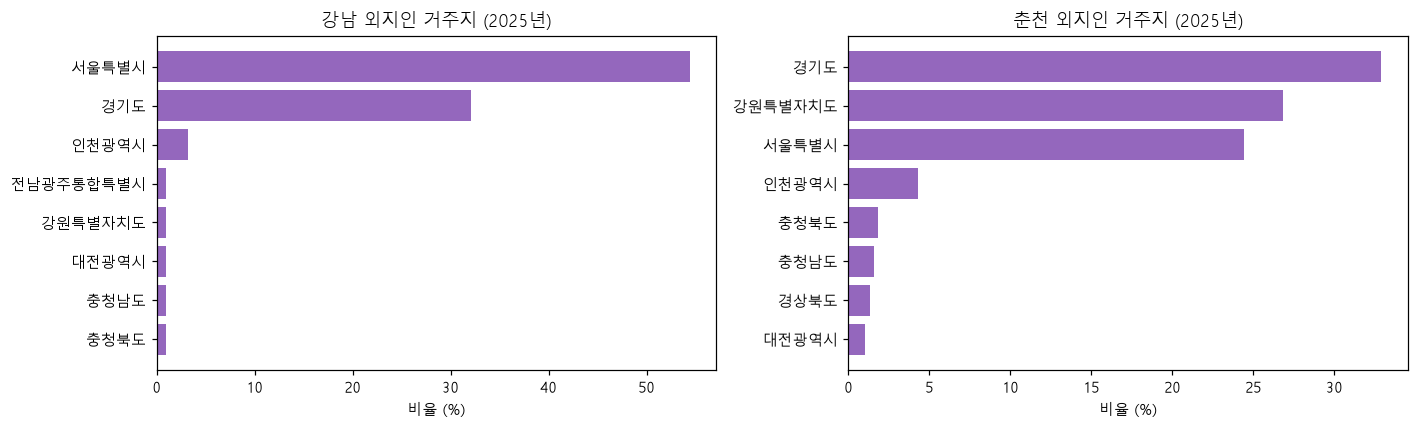

춘천 시군구 상위 10


,home_sido,home_sgg,share
2275,강원특별자치도,홍천군,5.6
2232,경기도,남양주시,4.8
2276,강원특별자치도,원주시,4.7
2277,강원특별자치도,화천군,4.4
2233,경기도,가평군,4.0
2278,강원특별자치도,양구군,3.0
2292,서울특별시,송파구,2.0
2279,강원특별자치도,강릉시,1.9
2280,강원특별자치도,인제군,1.8
2293,서울특별시,강동구,1.8


In [32]:
home = tour['tour_dom_home']
h25 = home[home['year'].eq(2025)]
시도 = h25.groupby(['region', 'home_sido'])['share'].sum()
print('연도별 비율 합계(%):'); display(home.groupby(['region', 'year'])['share'].sum().round(1).unstack())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, ['강남', '춘천']):
    t = 시도.loc[r].nlargest(8)
    ax.barh(t.index, t.values, color=SOURCE_COLOR['관광'])
    ax.invert_yaxis(); ax.set(xlabel='비율 (%)', title=f'{r} 외지인 거주지 (2025년)')
plt.tight_layout(); plt.show()

print('춘천 시군구 상위 10')
display(h25[h25['region'].eq('춘천')].nlargest(10, 'share')[['home_sido', 'home_sgg', 'share']].round(1))

### 7장 정리
- **본 것**: 월별 방문자 추이(7-1), 계절성(7-2), 2025년 하반기(7-3), 외지인 거주지(7-4)
- **나온 것**:
  - 두 지역 모두 코로나 이후 꾸준히 늘어 **2025년이 5년 중 최대**(강남 4억 2,966만, 춘천 1억 1,630만)
  - 외지인 비중은 강남 53.4%, **춘천 26.1%** 다. 춘천 방문자의 4분의 3은 현지인이다
  - **폭염이 심했던 7~8월에도 방문자는 전년보다 늘었다**(춘천 외지인 +5.9%, +2.3% / 강남 전체 +6.9%, +6.5%)
  - 9월과 10월의 큰 증감은 **추석 위치 차이**(2024년 9월 → 2025년 10월) 때문이다. 춘천은 명절에 늘고 강남은 줄어든다
  - 춘천 외지인의 26.8%가 같은 강원(홍천 5.6%, 원주 4.7%, 화천 4.4% 등 이웃 시군)
- **시사점**:
  - **월 단위로는 폭염의 흔적이 없다.** 분기 매출과 같은 이유로, 며칠짜리 효과가 월 합계에 묻힌다
  - 전년 비교에서는 **명절 위치를 반드시 확인**해야 한다. 9월과 10월을 따로 보면 잘못 읽는다
  - 춘천 외지인의 4분의 1이 같은 강원 사람이라 **카드에서는 이들이 현지인으로 잡힌다**. 8장에서 정의를 맞춘다

## 8. 관광 방문자와 카드 외지인 매출 교차검증
카드 데이터2의 외지인 매출 비중(02번 9장)이 실제 방문 흐름과 맞는지 관광 자료로 확인한다.
두 자료가 겹치는 기간은 **2025년 7~12월, 6개월**뿐이라 지역마다 점이 6개이다. 상관계수는 참고용으로만 읽는다.

### 8-1. 카드 데이터2 월별 외지인 매출 비중

In [33]:
LOCAL = {'강남': '서울', '춘천': '강원'}
base2 = base2.copy()
base2['is_outsider'] = ~base2['residence'].isin(['정보없음']) & \
                        (base2['residence'] != base2['region'].map(LOCAL))
base2['mon'] = base2['date'].dt.month

카드비중 = (base2.groupby(['region', 'mon']).apply(
    lambda d: pd.Series({'금액 비중': d.loc[d['is_outsider'], 'amount'].sum() / d['amount'].sum() * 100,
                         '건수 비중': d.loc[d['is_outsider'], 'cnt'].sum() / d['cnt'].sum() * 100}),
    include_groups=False))
display(카드비중.round(1).unstack('mon'))

전체card2 = card2.copy()
전체card2['is_outsider'] = ~전체card2['residence'].isin(['정보없음']) & \
                           (전체card2['residence'] != 전체card2['region'].map(LOCAL))
참고 = 전체card2.groupby('region').apply(
    lambda d: d.loc[d['is_outsider'], 'amount'].sum() / d['amount'].sum() * 100, include_groups=False)
print('(참고) is_target 조건 없이 card2 전체:', 참고.round(1).to_dict())

금액 비중                          건수 비중                         
mon       7    8    9    10   11   12    7    8    9    10   11   12
region                                                              
강남      47.7 47.5 48.4 47.9 48.4 47.8  50.9 50.9 50.9 51.7 52.1 52.5
춘천      18.2 19.7 17.9 21.3 18.5 14.4  16.4 18.2 17.6 20.6 18.3 15.9

(참고) is_target 조건 없이 card2 전체: {'강남': 62.8, '춘천': 20.9}


### 8-2. 관광 외지인 비중과 나란히 보기

관광 외지인 비중                          카드 외지인 매출 비중                      \
mon           7    8    9    10   11   12           7    8    9    10   11   
region                                                                       
강남          54.0 53.2 52.4 52.2 53.9 54.8         47.7 47.5 48.4 47.9 48.4   
춘천          25.6 28.3 26.0 29.8 25.1 21.9         18.2 19.7 17.9 21.3 18.5   

             
mon      12  
region       
강남     47.8  
춘천     14.4

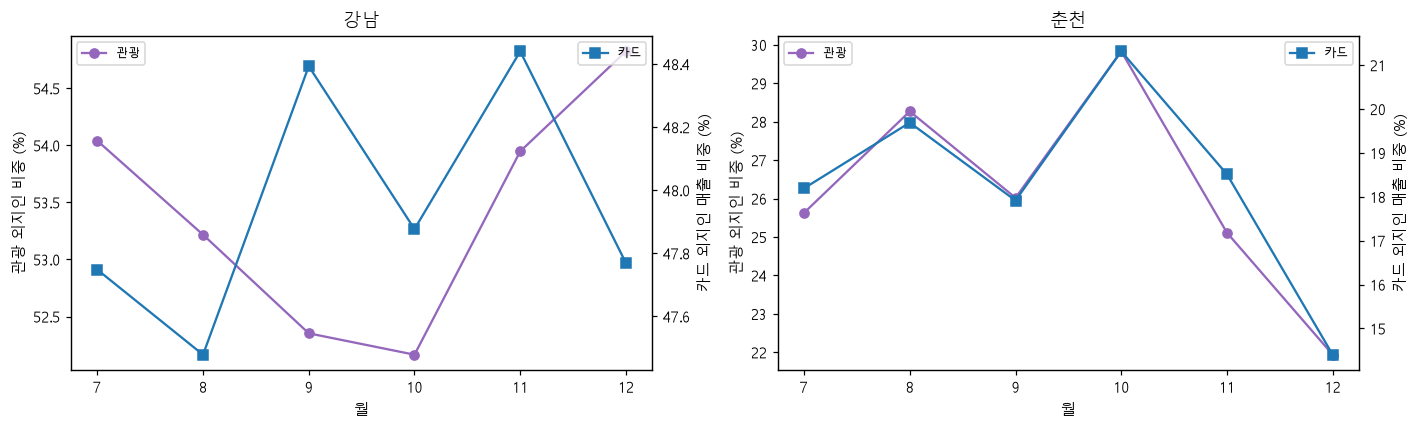

In [34]:
관광비중 = (trend.loc[(slice(None), slice('2025-07-01', '2025-12-01')), :]
           .assign(비중=lambda d: d['외지인'] / d['전체'] * 100)['비중'])
관광비중.index = pd.MultiIndex.from_arrays(
    [관광비중.index.get_level_values('region'), 관광비중.index.get_level_values('month').month], names=['region', 'mon'])

비교 = pd.DataFrame({'관광 외지인 비중': 관광비중, '카드 외지인 매출 비중': 카드비중['금액 비중']})
display(비교.round(1).unstack('mon'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, ['강남', '춘천']):
    t = 비교.loc[r]
    ax.plot(t.index, t['관광 외지인 비중'], marker='o', color=SOURCE_COLOR['관광'], label='관광')
    ax2 = ax.twinx()
    ax2.plot(t.index, t['카드 외지인 매출 비중'], marker='s', color=SOURCE_COLOR['카드'], label='카드')
    ax.set(xlabel='월', ylabel='관광 외지인 비중 (%)', title=r); ax2.set_ylabel('카드 외지인 매출 비중 (%)')
    ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### 8-3. 외지인 정의 맞추기

In [35]:
SIDO = {'강남': '서울특별시', '춘천': '강원특별자치도'}
같은시도 = {}
for r in ['강남', '춘천']:
    t = home[home['year'].eq(2025) & home['region'].eq(r)]
    같은시도[r] = t.loc[t['home_sido'].eq(SIDO[r]), 'share'].sum() / t['share'].sum()
print('같은 시도 비율:', {k: round(v, 3) for k, v in 같은시도.items()})

비교['조정 비중'] = 비교['관광 외지인 비중'] * (1 - 비교.index.get_level_values('region').map(같은시도))
display(비교.round(1).unstack('mon'))
print('6개월 평균'); display(비교.groupby('region').mean().round(1))
print('※ 월별 거주지 자료가 없어 2025년 연간 비율을 모든 달에 똑같이 썼다 (한계).')

같은 시도 비율: {'강남': 0.553, '춘천': 0.27}


관광 외지인 비중                          카드 외지인 매출 비중                      \
mon           7    8    9    10   11   12           7    8    9    10   11   
region                                                                       
강남          54.0 53.2 52.4 52.2 53.9 54.8         47.7 47.5 48.4 47.9 48.4   
춘천          25.6 28.3 26.0 29.8 25.1 21.9         18.2 19.7 17.9 21.3 18.5   

            조정 비중                           
mon      12    7    8    9    10   11   12  
region                                      
강남     47.8  24.1 23.8 23.4 23.3 24.1 24.5  
춘천     14.4  18.7 20.6 19.0 21.8 18.3 16.0

6개월 평균


,관광 외지인 비중,카드 외지인 매출 비중,조정 비중
region,,,
강남,53.4,48.0,23.9
춘천,26.1,18.3,19.1


※ 월별 거주지 자료가 없어 2025년 연간 비율을 모든 달에 똑같이 썼다 (한계).


### 8-4. 상관계수와 해석

,관광 vs 카드 금액,조정 vs 카드 금액,관광 vs 카드 건수
region,,,
강남,-0.2,-0.2,0.5
춘천,1.0,1.0,0.8


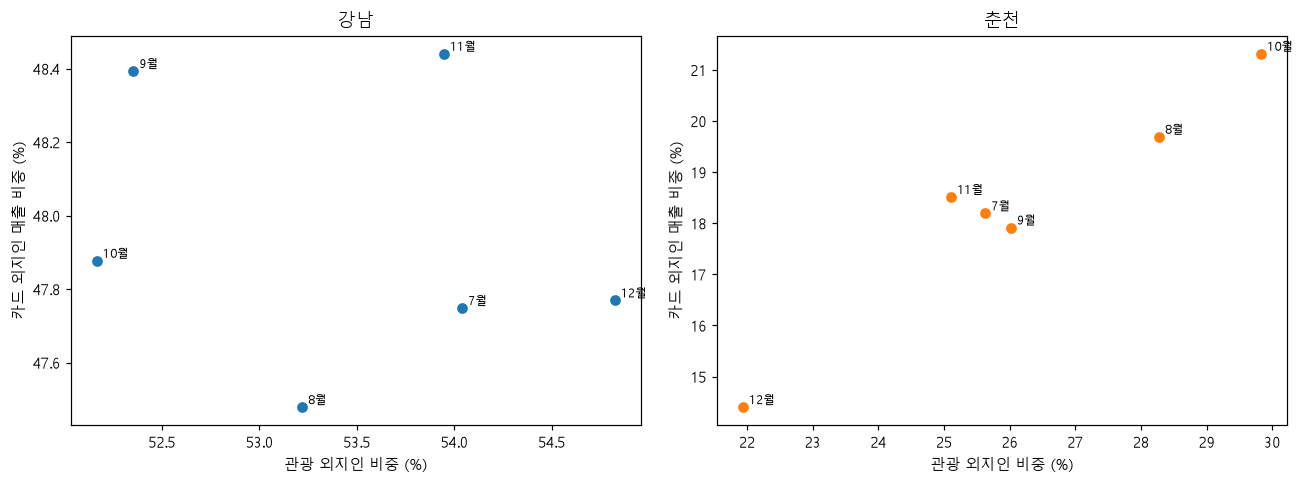

In [36]:
비교['카드 건수 비중'] = 카드비중['건수 비중']
행 = []
for r in ['강남', '춘천']:
    t = 비교.loc[r]
    행.append({'region': r,
               '관광 vs 카드 금액': t['관광 외지인 비중'].corr(t['카드 외지인 매출 비중']),
               '조정 vs 카드 금액': t['조정 비중'].corr(t['카드 외지인 매출 비중']),
               '관광 vs 카드 건수': t['관광 외지인 비중'].corr(t['카드 건수 비중'])})
display(pd.DataFrame(행).set_index('region').round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, r in zip(axes, ['강남', '춘천']):
    t = 비교.loc[r]
    ax.scatter(t['관광 외지인 비중'], t['카드 외지인 매출 비중'], color=REGION_COLOR[r])
    for m in t.index:
        ax.annotate(f'{m}월', (t.loc[m, '관광 외지인 비중'], t.loc[m, '카드 외지인 매출 비중']),
                    fontsize=8, xytext=(4, 2), textcoords='offset points')
    ax.set(xlabel='관광 외지인 비중 (%)', ylabel='카드 외지인 매출 비중 (%)', title=r)
plt.tight_layout(); plt.show()

### 8-5. 방문자 수와 매출 금액 (월별)

In [37]:
방문 = trend.reset_index()
방문 = 방문[방문['month'].dt.year.eq(2025) & 방문['month'].dt.month.between(7, 12)]
방문['mon'] = 방문['month'].dt.month

카드금액 = (base2.groupby(['region', 'mon']).apply(
    lambda d: pd.Series({'외지인 금액': d.loc[d['is_outsider'], 'amount'].sum()}), include_groups=False).reset_index())
b1 = base1.assign(mon=base1['date'].dt.month).groupby(['region', 'mon'])['amount'].sum().rename('base1 월매출').reset_index()

t = 방문[['region', 'mon', '외지인', '전체']].merge(카드금액, on=['region', 'mon']).merge(b1, on=['region', 'mon'])
t['방문 1회당 외지인 매출(원)'] = t['외지인 금액'] / t['외지인']

행 = []
for r in ['강남', '춘천']:
    g = t[t['region'].eq(r)]
    행.append({'region': r,
               '외지인 방문 vs 외지인 매출': g['외지인'].corr(g['외지인 금액']),
               '전체 방문 vs base1 월매출': g['전체'].corr(g['base1 월매출']),
               '방문 1회당 매출(원) 평균': g['방문 1회당 외지인 매출(원)'].mean()})
display(pd.DataFrame(행).set_index('region').round(2))
display(t.set_index(['region', 'mon'])[['방문 1회당 외지인 매출(원)']].round(0).unstack('mon'))

,외지인 방문 vs 외지인 매출,전체 방문 vs base1 월매출,방문 1회당 매출(원) 평균
region,,,
강남,0.6,0.4,"39,153.1"
춘천,1.0,0.9,"17,144.1"


방문 1회당 외지인 매출(원)                                             
mon                  7        8        9        10       11       12
region                                                              
강남             37,341.0 38,710.0 38,398.0 41,796.0 37,675.0 40,997.0
춘천             17,353.0 16,787.0 16,601.0 17,740.0 18,067.0 16,317.0

**결정**: 관광 자료 교차검증 결과를 05번 외지인 분석에 어떻게 쓸지 적어 둔다.

- **결정**: **춘천은 카드2 외지인 비중을 방문 흐름의 대리 지표로 쓴다. 강남은 외지인 = 출퇴근 인구로 해석하고 관광 해석을 하지 않는다.**
- **이유**: 춘천은 두 자료의 상관이 0.97이고, 정의를 맞추면 수준까지 19.1% 대 18.3%로 거의 같다.
  강남은 상관이 -0.20이고 조정하면 23.9% 대 48.0%로 오히려 두 배 차이가 난다.
  카드 외지인 매출의 대부분이 경기와 인천에서 오는 **출퇴근 인구**인데, 관광 자료는 매일 반복되는 통근 이동을 방문으로 덜 세는 것으로 보인다.

### 8장 정리
- **본 것**: 카드 외지인 비중(8-1), 관광 비중과 나란히(8-2), 정의 맞추기(8-3), 상관(8-4), 양끼리 비교(8-5)
- **나온 것**:
  - 카드 외지인 매출 비중: 춘천 14.4~21.3%(달마다 크게 오르내림), **강남 47.5~48.4%(거의 변하지 않음)**
  - 관광 외지인 비중: 춘천 21.9~29.8%, 강남 52.2~54.8%
  - 정의를 맞추면(같은 시도 사람 제외) **춘천은 19.1% 대 18.3%로 거의 같아진다.** 강남은 23.9% 대 48.0%로 벌어진다
  - 상관: **춘천 0.97, 강남 -0.20**. 건수 기준으로는 춘천 0.85, 강남 0.50
  - 방문자 수와 매출도 춘천은 같이 움직인다(외지인 0.97, 전체 0.89). 강남은 0.64, 0.43
- **시사점**:
  - **춘천에서는 "외지인 매출 감소 = 방문 감소"로 읽어도 된다.** 07번 Q6에서 비 오는 날 춘천 외지인이 먼저 빠진 것(0.86)과 앞뒤가 맞는다
  - 강남은 외지인 비중이 1%p 안에서만 움직여 **상관을 논할 만한 변동 자체가 없다**

## 9. 외국인 방문자
외국인 방문은 강남 상권의 중요한 맥락이다. 다만 **카드 데이터에는 외국인 결제가 따로 표시되지 않는다** (카드 데이터2의 거주지는 국내 시도 16개와 '정보없음'뿐).
그래서 이 장은 배경 설명용이다.

### 9-1. 외국인 방문자 추이

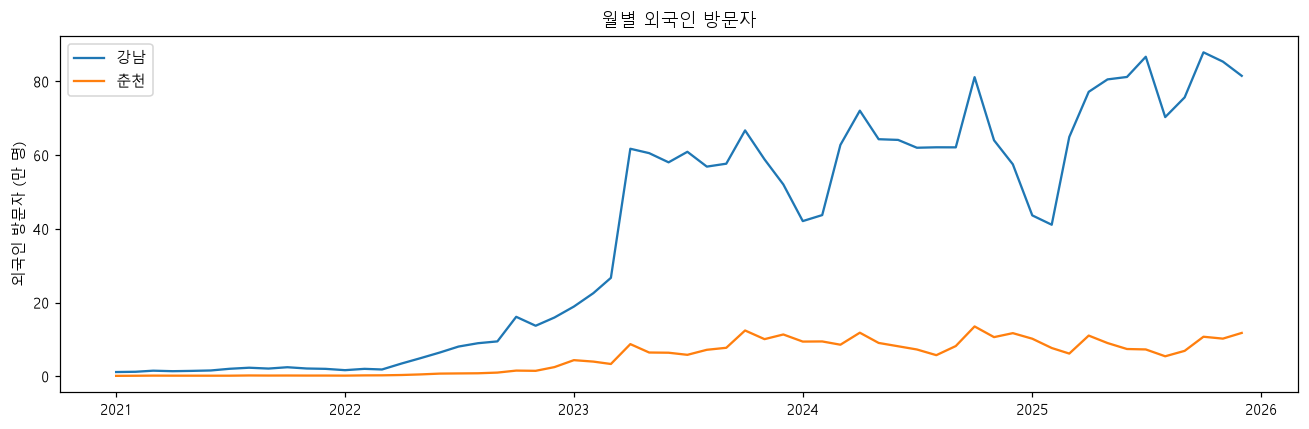

연간 합계(만 명)


region,강남,춘천
year,,
2021,21.2,2.0
2022,92.5,10.2
2023,601.5,87.7
2024,738.0,113.4
2025,876.1,103.7


2025년 하반기(만 명)


month,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
region,,,,,,
강남,86.7,70.3,75.7,87.9,85.4,81.5
춘천,7.3,5.4,6.9,10.7,10.2,11.8


전년 대비(%)


month,7,8,9,10,11,12
region,,,,,,
강남,39.8,13.2,21.8,8.3,33.3,41.7
춘천,0.2,-5.3,-15.9,-20.7,-3.9,0.5


외국인 / 내국인 방문자(%): {'강남': 2.0, '춘천': 0.9}


In [38]:
ft = tour['tour_for_trend'].pivot_table(index='month', columns='region', values='visitors') / 1e4
fig, ax = plt.subplots(figsize=(12, 4))
for r in ['강남', '춘천']:
    ax.plot(ft.index, ft[r], label=r, color=REGION_COLOR[r])
ax.set(ylabel='외국인 방문자 (만 명)', title='월별 외국인 방문자'); ax.legend()
plt.tight_layout(); plt.show()

연 = ft.copy(); 연['year'] = 연.index.year
print('연간 합계(만 명)'); display(연.groupby('year')[['강남', '춘천']].sum().round(1))

h25 = ft[(ft.index.year == 2025) & (ft.index.month >= 7)]
h24 = ft[(ft.index.year == 2024) & (ft.index.month >= 7)]
print('2025년 하반기(만 명)'); display(h25.round(1).T)
yoy = (h25.values / h24.values - 1) * 100
print('전년 대비(%)'); display(pd.DataFrame(yoy, index=h25.index.month, columns=ft.columns).round(1).T)

내국인 = trend['전체'].reset_index()
내국인 = 내국인[내국인['month'].dt.year.eq(2025)].groupby('region')['전체'].sum()
외국인 = 연[연['year'] == 2025][['강남', '춘천']].sum() * 1e4
print('외국인 / 내국인 방문자(%):', (외국인 / 내국인 * 100).round(1).to_dict())

### 9-2. 국적과 방문 행정동

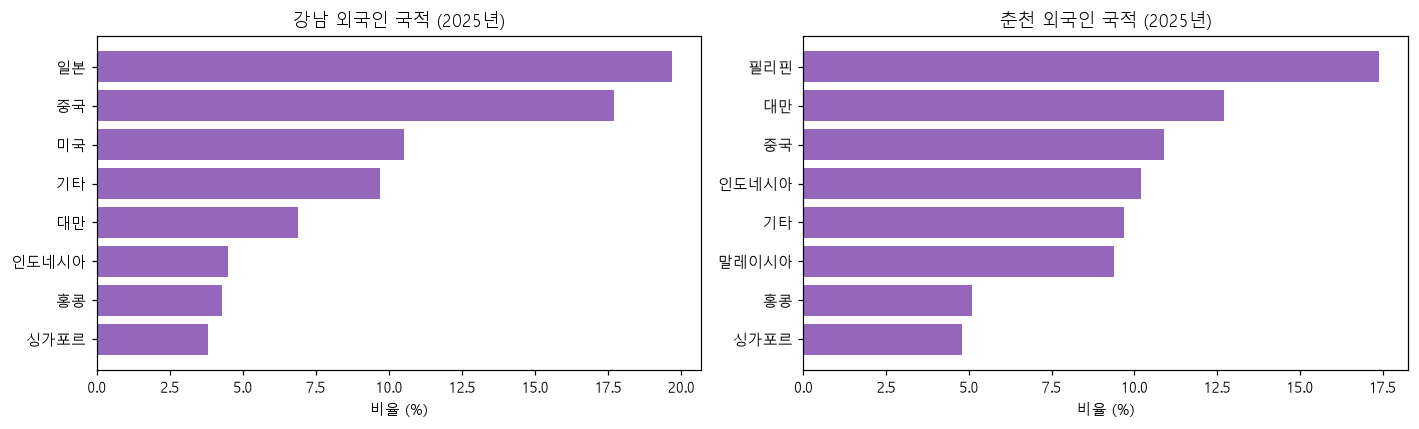

강남 연도별 국적 비율(%)


year,2021,2022,2023,2024,2025
country,,,,,
기타,16.1,14.7,8.8,9.7,9.7
대만,0.1,2.6,10.9,10.0,6.9
미국,44.6,14.6,10.2,6.1,10.5
인도네시아,3.2,2.6,4.2,5.2,4.5
일본,1.8,13.7,18.1,18.9,19.7
중국,10.9,4.6,14.5,14.8,17.7


강남 외국인 상위 5개 동: [('삼성1동', '277.7만', '19.4%'), ('역삼1동', '233.7만', '16.4%'), ('압구정동', '175.6만', '12.3%'), ('신사동', '155.0만', '10.8%'), ('논현1동', '113.6만', '8.0%')]
춘천 외국인 상위 5개 동: [('남산면', '66.8만', '39.5%'), ('신동면', '14.5만', '8.6%'), ('서면', '14.2만', '8.4%'), ('강남동', '8.0만', '4.8%'), ('근화동', '7.9만', '4.7%')]
강남 내국인 상위 5개 동: [('역삼1동', '5923.9만', '19.8%'), ('삼성1동', '2778.3만', '9.3%'), ('압구정동', '2314.5만', '7.7%'), ('신사동', '1914.3만', '6.4%'), ('청담동', '1843.7만', '6.2%')]
춘천 내국인 상위 5개 동: [('강남동', '576.9만', '10.5%'), ('퇴계동', '520.5만', '9.4%'), ('남산면', '494.5만', '9.0%'), ('석사동', '409.1만', '7.4%'), ('소양동', '340.6만', '6.2%')]


In [39]:
country = tour['tour_for_country']
c25 = country[country['year'].eq(2025)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, ['강남', '춘천']):
    t = c25[c25['region'].eq(r)].nlargest(8, 'share')
    ax.barh(t['country'], t['share'], color=SOURCE_COLOR['관광'])
    ax.invert_yaxis(); ax.set(xlabel='비율 (%)', title=f'{r} 외국인 국적 (2025년)')
plt.tight_layout(); plt.show()

상위6 = c25[c25['region'].eq('강남')].nlargest(6, 'share')['country']
print('강남 연도별 국적 비율(%)')
display(country[country['region'].eq('강남') & country['country'].isin(상위6)]
        .pivot_table(index='country', columns='year', values='share').round(1))

for 이름, key in [('외국인', 'tour_for_dong'), ('내국인', 'tour_dom_dong')]:
    d = tour[key]
    d = d[d['year'].eq(2025)]
    for r in ['강남', '춘천']:
        t = d[d['region'].eq(r)].nlargest(5, 'visitors')
        총 = d.loc[d['region'].eq(r), 'visitors'].sum()
        print(f"{r} {이름} 상위 5개 동:",
              [(x.dong, f'{x.visitors / 1e4:.1f}만', f'{x.visitors / 총:.1%}') for x in t.itertuples()])

### 9장 정리
- **본 것**: 외국인 방문자 추이(9-1), 국적과 방문 행정동(9-2)
- **나온 것**:
  - 강남 외국인은 2021년 21.2만 → 2025년 876.1만으로 **40배 넘게** 늘었고 2025년에도 증가 중(YoY +8~42%)
  - **강남 외국인은 8월이 가장 적다**(70.3만). 7월 86.7만, 10월 87.9만보다 뚜렷하게 낮다
  - 춘천 외국인은 2024년 113.4만에서 2025년 103.7만으로 **줄었다**(9월 -15.9%, 10월 -20.7%)
  - 국적은 강남이 일본 19.7%, 중국 17.7%, 미국 10.5% / 춘천은 필리핀 17.4%, 대만 12.7% 등 동남아 비중이 높다
  - 외국인이 가는 동은 강남 삼성1동, 역삼1동, 압구정동(상위 3개가 48%), 춘천은 남산면(남이섬)
- **시사점**:
  - **카드 데이터로는 외국인 결제를 분리할 수 없다**(거주지가 국내 시도 16개와 정보없음뿐). 이 장은 배경 설명용이다
  - > [추론] 강남 외국인이 8월에 가장 적은 것이 더위 때문인지 여름 비수기 때문인지는 이 자료로 구분할 수 없다

## 10. 전체 정리

### 10-1. 외부 자료로 할 수 있는 것과 없는 것

| 자료 | 단위 | 할 수 있는 것 | 할 수 없는 것 | 근거 (몇 장) |
|---|---|---|---|---|
| 서울 상권매출 | 분기, 강남 행정동 | 카드 데이터 구성(업종, 요일, 성별, 연령)의 대표성 확인, 5년 추세 속 2025년 3분기 위치 | 폭염일, 호우일 효과 (분기라서), 춘천 (서울만), 총액 비교, 그룹별 움직임 비교 | 3장, 4장 |
| 상가정보 | 10월, 12월 두 시점 | 두 지역 상권 교체율 비교, 업종과 동 사이 **상대** 비교 | 회복 지표(전 시점이 없음), 폐업률 절댓값(번호 재발급), 폭염 전후 비교 | 5장, 6장 |
| 관광 내국인 | 월, 시군구 | 춘천 카드 외지인 비중의 검증(상관 0.97), 명절 위치 효과 확인 | 폭염일 효과(월 단위), 강남 외지인 해석(상관 -0.20) | 7장, 8장 |
| 관광 외국인 | 월, 시군구 | 강남 상권의 외국인 규모와 국적, 방문 동 파악 | 카드와 연결(외국인 결제 식별 불가), 매출 기여 추정 | 9장 |

### 10-2. 다른 노트북으로 넘길 결정 사항

| 항목 | 결정 | 근거 (몇 장) |
|---|---|---|
| 상권매출 업종 -> 카드 업종그룹 사전 (애매한 업종 처리) | 63개 전부 연결. 화초와 안경은 생활/취미용품, 여관은 숙박/여행, 고시원과 전자상거래는 제외 | 2-1 |
| 카드 데이터 대표성 문장 (보고서용) | "업종그룹, 요일, 성별, 연령 구성과 분기 변화 방향이 상권매출과 일치. 단 식료품, 교통/차량, 숙박/여행, 패션/뷰티는 업종 범위가 달라 비교 불가" | 3장 결정 |
| 성별, 연령 비중을 낼 때의 분모 규칙 | **성별 합계 또는 연령 합계를 분모로.** 당월 매출을 쓰면 13% 빠짐 | 1-2 |
| 2025년 3분기가 평년과 달랐던 업종그룹 (05번에서 특히 볼 것) | **높았던 쪽**: 여가/오락, 카페, 편의점, 스포츠시설 / **낮았던 쪽**: 패션/뷰티(유일) | 4-5 |
| 상가정보 활용 범위 | 배경의 교체율 비교로만. 폐업 분석은 개폐업 원장(`bizreg`)으로 | 6장 결정 |
| 춘천 외지인 비중 해석 (방문 흐름 대리 지표로 쓸지) | **쓴다.** 상관 0.97, 정의 맞추면 수준도 일치 | 8장 결정 |
| 강남 외지인 해석 (출퇴근 인구) | **출퇴근 인구로 해석.** 관광 해석은 하지 않음(상관 -0.20, 변동 1%p) | 8-3 |
| 추석 위치 차이(2024년 9월, 2025년 10월)를 전년 비교에서 다루는 방법 | 9월과 10월은 **따로 보지 말고 두 달을 합쳐서** 전년과 비교 | 7-3 |

### 10-3. 더 확인할 것
- 2025년 3분기 카페 1.094, 편의점 1.077이 5년 중 가장 높았음 -> 05번에서 **폭염일에 카페와 편의점 매출이 오르는지** 확인 (07번 2-5에서 춘천 커피전문점 tmax 상관 +0.66)
- 패션/뷰티만 평년보다 낮았음(0.954 vs 0.974) -> 05번에서 이 그룹의 폭염 반응 확인 (07번 3-3에서 강남 의복/의류 폭염 효과 0.93)
- 2025년 6월 이전 상가정보 스냅샷을 구하면 폭염 전후 폐업 비교 가능 -> **개폐업 원장(`bizreg`)으로 이미 가능**하므로 그쪽을 쓴다
- > [추론] 강남 외국인이 8월에 가장 적은 이유(더위인지 여름 비수기인지)는 이 자료로 구분 불가. 연도별 8월을 비교하면 실마리가 될 수 있다